# Notebook Triển khai và Đánh giá Model trên Tập Test

**Mục đích:** Notebook này được thiết kế để tải một model đã được huấn luyện (`best_model.pth`) từ một lần chạy cụ thể, sau đó chạy inference trên toàn bộ tập test, tính toán các metrics hiệu suất và trực quan hóa kết quả.

## Bước 1: Cài đặt, Imports và Kết nối Google Drive

In [ ]:
%pip install -q cartopy

import os
import json
import math
import re
from collections import OrderedDict

import numpy as np
import pandas as pd
import xarray as xr
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 24.8 MB/s eta 0:00:00
Mounted at /content/drive


## Bước 2: Cấu hình
**QUAN TRỌNG:** Chỉnh sửa biến `TARGET_RUN_FOLDER` để trỏ đến thư mục training bạn muốn đánh giá.

In [ ]:
# =============================================================================
# 1. CẤU HÌNH ĐƯỜNG DẪN: CHỈ CẦN CHỈNH SỬA Ở ĐÂY
# =============================================================================
BASE_DIR = "/content/drive/MyDrive/era5_vn_min/processed"
CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints_advanced")

TARGET_RUN_FOLDER = "20251024_051938"  # <--- CHỈNH SỬA DÒNG NÀY
# =============================================================================

# --- 2. Cấu hình Dữ liệu và Model (PHẢI KHỚP VỚI LÚC TRAINING) ---
TEST_PATH  = os.path.join(BASE_DIR, "test_2024.nc")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 8

ALL_FEATURES = ['t2m', 'd2m', 'u10', 'v10', 'msl', 'sp', 'tp', 'ssrd', 'skt', 'tcwv']
TARGET_FEATURE = 'tp'
N_FEATURES = len(ALL_FEATURES)
SEQ_LEN = 4

N_LAT, N_LON = 65, 33
D_MODEL, N_HEADS, N_LAYERS, DROPOUT = 128, 8, 4, 0.1

# --- 3. Xây dựng đường dẫn cuối cùng ---
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, TARGET_RUN_FOLDER, "best_model.pth")

print(f"Sử dụng thiết bị: {DEVICE}")
print(f"Sẽ tải model tốt nhất từ: {BEST_MODEL_PATH}")
print(f"Sẽ chạy đánh giá trên file: {TEST_PATH}")

Sử dụng thiết bị: cuda
Sẽ tải model tốt nhất từ: /content/drive/MyDrive/era5_vn_min/processed/checkpoints_advanced/20251024_051938/best_model.pth
Sẽ chạy đánh giá trên file: /content/drive/MyDrive/era5_vn_min/processed/test_2024.nc


## Bước 3: Định nghĩa lại Kiến trúc Model và Lớp Dataset

In [ ]:
class Time2Vec(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Time2Vec, self).__init__()
        self.w0 = nn.parameter.Parameter(torch.randn(input_dim, 1))
        self.b0 = nn.parameter.Parameter(torch.randn(input_dim, 1))
        self.w = nn.parameter.Parameter(torch.randn(input_dim, output_dim - 1))
        self.b = nn.parameter.Parameter(torch.randn(input_dim, output_dim - 1))
    def forward(self, t):
        if t.dim() < 3: t = t.unsqueeze(-1)
        v_linear = torch.matmul(t, self.w0) + self.b0
        v_periodic = torch.sin(torch.matmul(t, self.w) + self.b)
        return torch.cat([v_linear, v_periodic], -1)

class FourierFeatures(nn.Module):
    def __init__(self, in_channels, d_model):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(in_channels * 2, d_model * 2), nn.GELU(), nn.Linear(d_model * 2, d_model))
    def forward(self, x):
        B, T, H, W, C = x.shape
        x = x.permute(0, 1, 4, 2, 3).reshape(B * T, C, H, W)
        fft_features = torch.fft.rfft2(x, norm='ortho')
        fft_features = torch.cat([fft_features.real, fft_features.imag], dim=1)
        pooled_features = F.adaptive_avg_pool2d(fft_features, 1).squeeze(-1).squeeze(-1)
        return self.mlp(pooled_features).view(B, T, 1, 1, -1)

class AdvancedConvTransformer(nn.Module):
    def __init__(self, n_features, seq_len, d_model, n_heads, n_layers, dropout, n_lat, n_lon):
        super().__init__()
        self.d_model = d_model
        # SỬA LỖI: Thêm padding=1 vào cả hai lớp Conv2d
        self.cnn_encoder = nn.Sequential(
            nn.Conv2d(n_features, d_model // 2, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(d_model // 2, d_model, kernel_size=3, padding=1)
        )
        self.lat_embed = nn.Embedding(n_lat, d_model)
        self.lon_embed = nn.Embedding(n_lon, d_model)
        self.time_encoder = Time2Vec(1, d_model)
        self.fourier_encoder = FourierFeatures(n_features, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model, n_heads, dropout=dropout, batch_first=True, activation=F.gelu)
        self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)
        self.output_proj = nn.Sequential(nn.Linear(d_model, d_model // 2), nn.GELU(), nn.Linear(d_model // 2, 1))
    def forward(self, x, time_indices):
        B, T, H, W, C = x.shape; device = x.device
        x_reshaped = x.permute(0, 1, 4, 2, 3).reshape(B * T, C, H, W)
        cnn_features = self.cnn_encoder(x_reshaped).view(B, T, self.d_model, H, W).permute(0, 1, 3, 4, 2)
        lat_indices = torch.arange(H, device=device).view(1, 1, H, 1).expand(B, T, -1, W)
        lon_indices = torch.arange(W, device=device).view(1, 1, 1, W).expand(B, T, H, -1)
        spatial_embedding = self.lat_embed(lat_indices) + self.lon_embed(lon_indices)
        time_embedding = self.time_encoder(time_indices.float()).view(B, T, 1, 1, self.d_model)
        fourier_embedding = self.fourier_encoder(x)
        x_embedded = cnn_features + spatial_embedding + time_embedding + fourier_embedding
        transformer_input = x_embedded.view(B, T, H * W, self.d_model).permute(0, 2, 1, 3).reshape(B * H * W, T, self.d_model)
        transformer_output = self.transformer(transformer_input)
        last_step_output = transformer_output[:, -1, :].view(B, H, W, self.d_model)
        return self.output_proj(last_step_output).squeeze(-1)

class ERA5Dataset(Dataset):
    def __init__(self, nc_path, seq_len, features, target_feature):
        self.ds = xr.open_dataset(nc_path)
        self.seq_len, self.features, self.target_idx = seq_len, features, features.index(target_feature)
        self.data = np.stack([self.ds[f].values for f in self.features], axis=-1)
        self.indices = np.arange(self.data.shape[0] - self.seq_len)
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        start_idx, end_idx = self.indices[idx], self.indices[idx] + self.seq_len
        return torch.tensor(self.data[start_idx:end_idx, ...], dtype=torch.float32), torch.tensor(self.data[end_idx, ..., self.target_idx], dtype=torch.float32), torch.arange(self.seq_len)

print("Đã định nghĩa xong các class cần thiết.")

Đã định nghĩa xong các class cần thiết.


## Bước 4: Tải Model và Dữ liệu Test

In [ ]:
model = AdvancedConvTransformer(N_FEATURES, SEQ_LEN, D_MODEL, N_HEADS, N_LAYERS, DROPOUT, N_LAT, N_LON).to(DEVICE)
if os.path.exists(BEST_MODEL_PATH):
    print("Đang tải trọng số từ file best_model.pth...")
    checkpoint_state_dict = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
    if any(key.startswith('_orig_mod.') for key in checkpoint_state_dict.keys()):
        new_state_dict = OrderedDict()
        for k, v in checkpoint_state_dict.items():
            name = k.replace('_orig_mod.', '')
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)
    else:
        model.load_state_dict(checkpoint_state_dict)
    print("✅ Tải trọng số thành công.")
else:
    print(f"❌ LỖI: Không tìm thấy file model tại '{BEST_MODEL_PATH}'")

model = torch.compile(model)
model.eval()

test_dataset = ERA5Dataset(TEST_PATH, SEQ_LEN, ALL_FEATURES, TARGET_FEATURE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Model và dữ liệu test đã sẵn sàng.")

Đang tải trọng số từ file best_model.pth...
✅ Tải trọng số thành công.
Model và dữ liệu test đã sẵn sàng.


## Bước 5: Chạy Inference

In [ ]:
all_predictions = []
all_ground_truths = []

with torch.no_grad():
    for x_batch, y_batch, time_indices_batch in tqdm(test_loader, desc="Chạy Inference trên tập Test"):
        x_batch = x_batch.to(DEVICE)
        time_indices_batch = time_indices_batch.to(DEVICE)
        # Removed torch.amp.autocast context as DEVICE is not 'cuda'
        y_pred = model(x_batch, time_indices_batch)
        all_predictions.append(y_pred.cpu())
        all_ground_truths.append(y_batch.cpu())

predictions_tensor = torch.cat(all_predictions, dim=0)
ground_truths_tensor = torch.cat(all_ground_truths, dim=0)

print(f"\nInference hoàn tất.")

Chạy Inference trên tập Test:   0%|          | 0/549 [00:00<?, ?it/s]W1025 01:23:12.332000 306 torch/_inductor/utils.py:1436] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:1890: UserWarning: Torchinductor does not support code generation for complex operators. Performance may be worse than eager.
  warnings.warn(
Chạy Inference trên tập Test: 100%|██████████| 549/549 [02:18<00:00,  3.96it/s]


Inference hoàn tất.


## Bước 6: Tính toán và Hiển thị Metrics Cuối cùng

In [ ]:
y_true_flat = ground_truths_tensor.numpy().flatten()
y_pred_flat = predictions_tensor.numpy().flatten()
mse = mean_squared_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_flat, y_pred_flat)
r2 = r2_score(y_true_flat, y_pred_flat)
corr, _ = pearsonr(y_true_flat, y_pred_flat)
bias = np.mean(y_pred_flat - y_true_flat)
print("=======================================================")
print(f"|   KẾT QUẢ ĐÁNH GIÁ MODEL TRÊN TẬP TEST ({TARGET_RUN_FOLDER})   |")
print("=======================================================")
print(f"| METRICS VỀ SAI SỐ (càng nhỏ càng tốt)             |")
print(f"|-----------------------------------------------------|")
print(f"| Mean Squared Error (MSE)      : {mse:<18.6f} |")
print(f"| Root Mean Squared Error (RMSE): {rmse:<18.6f} |  -> Cùng đơn vị với dữ liệu gốc")
print(f"| Mean Absolute Error (MAE)     : {mae:<18.6f} |")
print("|-----------------------------------------------------|")
print(f"| METRICS VỀ MỨC ĐỘ PHÙ HỢP (càng gần 1 càng tốt)    |")
print("|-----------------------------------------------------|")
print(f"| R-squared (R²)                : {r2:<18.6f} |  -> Tỉ lệ phương sai được giải thích")
print(f"| Pearson Correlation (r)       : {corr:<18.6f} |  -> Mức độ tương quan tuyến tính")
print("|-----------------------------------------------------|")
print(f"| METRIC VỀ THIÊN VỊ (càng gần 0 càng tốt)          |")
print("|-----------------------------------------------------|")
print(f"| Bias                          : {bias:<18.6f} |  -> >0: over-predict, <0: under-predict")
print("=======================================================")

|   KẾT QUẢ ĐÁNH GIÁ MODEL TRÊN TẬP TEST (20251024_051938)   |
| METRICS VỀ SAI SỐ (càng nhỏ càng tốt)             |
|-----------------------------------------------------|
| Mean Squared Error (MSE)      : 0.331245           |
| Root Mean Squared Error (RMSE): 0.575539           |  -> Cùng đơn vị với dữ liệu gốc
| Mean Absolute Error (MAE)     : 0.267173           |
|-----------------------------------------------------|
| METRICS VỀ MỨC ĐỘ PHÙ HỢP (càng gần 1 càng tốt)    |
|-----------------------------------------------------|
| R-squared (R²)                : 0.671868           |  -> Tỉ lệ phương sai được giải thích
| Pearson Correlation (r)       : 0.821715           |  -> Mức độ tương quan tuyến tính
|-----------------------------------------------------|
| METRIC VỀ THIÊN VỊ (càng gần 0 càng tốt)          |
|-----------------------------------------------------|
| Bias                          : 0.026257           |  -> >0: over-predict, <0: under-predict


## Bước 7: Trực quan hóa Kết quả

Đang vẽ một vài ví dụ trực quan...


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


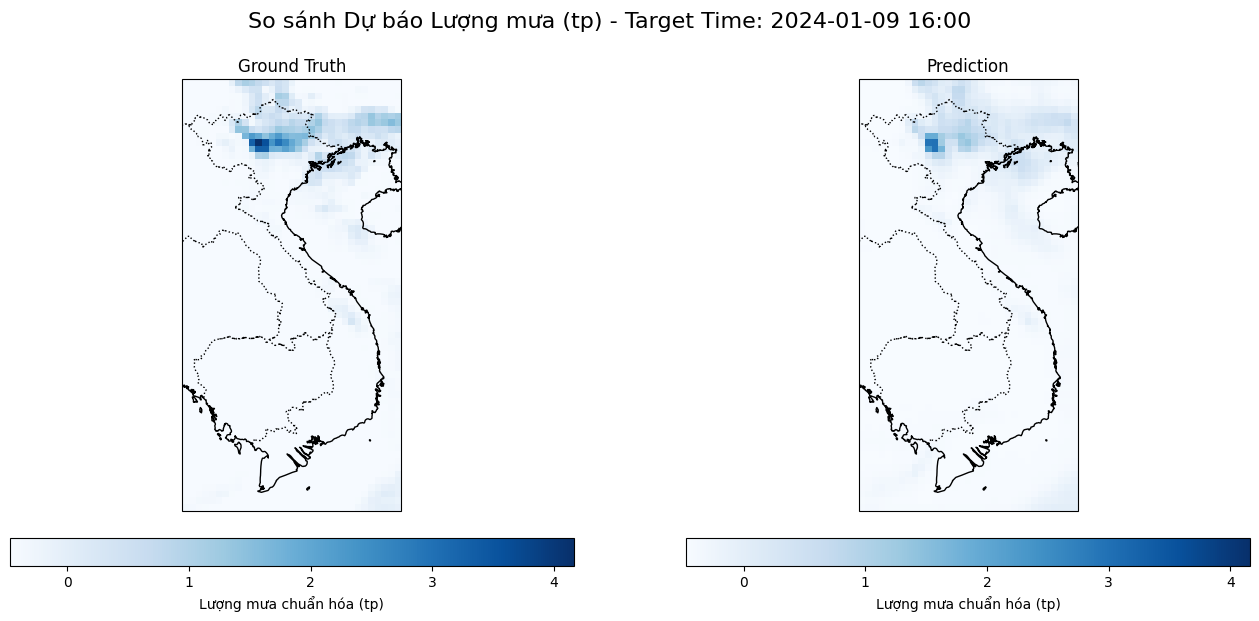

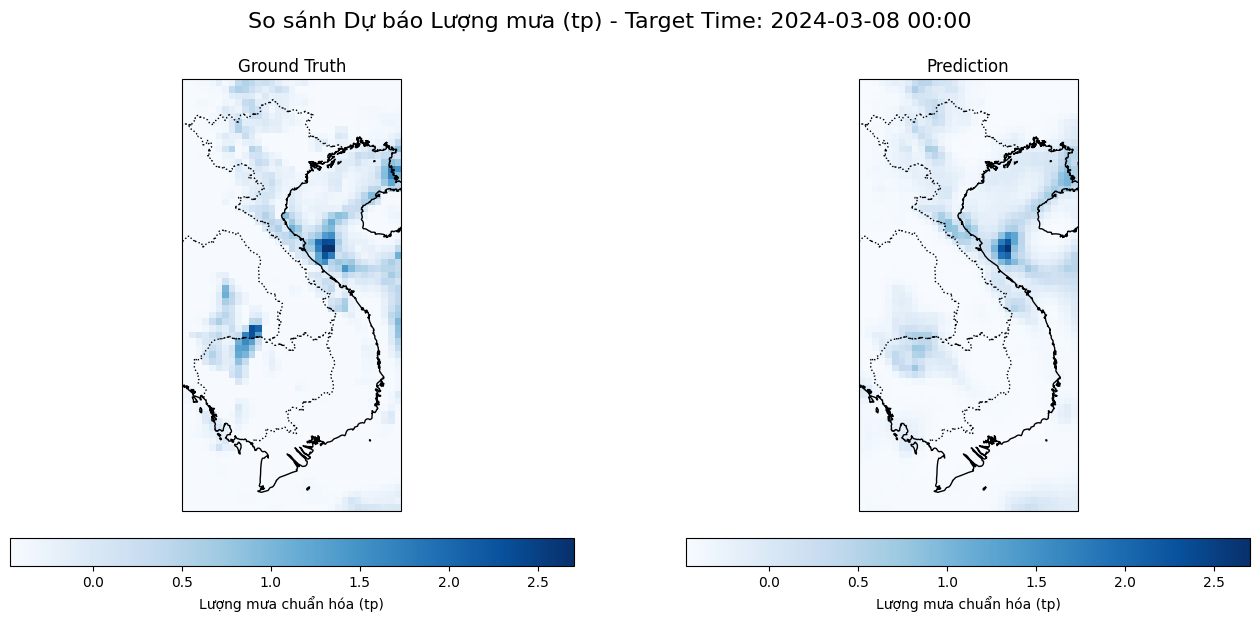

In [ ]:
def plot_prediction_vs_truth(t_idx):
    y_true, y_pred = ground_truths_tensor[t_idx].numpy(), predictions_tensor[t_idx].numpy()
    lat_vals, lon_vals = test_dataset.ds['latitude'].values, test_dataset.ds['longitude'].values
    target_raw_idx = test_dataset.indices[t_idx] + SEQ_LEN
    time_val = test_dataset.ds['valid_time'].values[target_raw_idx]
    time_str = pd.to_datetime(time_val).strftime('%Y-%m-%d %H:%M')
    vmin, vmax = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), subplot_kw={'projection': ccrs.PlateCarree()})
    fig.suptitle(f'So sánh Dự báo Lượng mưa (tp) - Target Time: {time_str}', fontsize=16)
    pcm0 = axes[0].pcolormesh(lon_vals, lat_vals, y_true, cmap='Blues', vmin=vmin, vmax=vmax, shading='auto')
    axes[0].add_feature(cfeature.COASTLINE); axes[0].add_feature(cfeature.BORDERS, linestyle=':')
    axes[0].set_title("Ground Truth"); fig.colorbar(pcm0, ax=axes[0], orientation='horizontal', pad=0.05, label='Lượng mưa chuẩn hóa (tp)')
    pcm1 = axes[1].pcolormesh(lon_vals, lat_vals, y_pred, cmap='Blues', vmin=vmin, vmax=vmax, shading='auto')
    axes[1].add_feature(cfeature.COASTLINE); axes[1].add_feature(cfeature.BORDERS, linestyle=':')
    axes[1].set_title("Prediction"); fig.colorbar(pcm1, ax=axes[1], orientation='horizontal', pad=0.05, label='Lượng mưa chuẩn hóa (tp)')
    plt.show()

print("Đang vẽ một vài ví dụ trực quan...")
plot_prediction_vs_truth(t_idx=100)
plot_prediction_vs_truth(t_idx=800)

##aio

In [ ]:
# =============================================================================
# CELL 1: CÀI ĐẶT FONT TIẾNG VIỆT CHO MATPLOTLIB
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Tải font hỗ trợ Unicode (DejaVu Sans)
!wget https://github.com/google/fonts/raw/main/apache/dejavusans/DejaVuSans.ttf -O /usr/share/fonts/truetype/DejaVuSans.ttf

# Xóa cache của matplotlib để nó nhận diện font mới
!rm -rf ~/.cache/matplotlib

# Thiết lập các tham số cho plot
# Cần phải khởi động lại runtime sau khi chạy cell này để font được áp dụng
# Tuy nhiên, chúng ta có thể thử set thủ công trước
font_path = '/usr/share/fonts/truetype/DejaVuSans.ttf'
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False # Để hiển thị dấu trừ đúng

print("Đã cài đặt font 'DejaVu Sans'. Vui lòng kiểm tra các biểu đồ bên dưới.")
print("Nếu vẫn lỗi font, hãy chọn 'Runtime' -> 'Restart runtime' và chạy lại từ đầu cell code chính bên dưới.")

--2025-10-25 01:25:25--  https://github.com/google/fonts/raw/main/apache/dejavusans/DejaVuSans.ttf
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-10-25 01:25:26 ERROR 404: Not Found.

Đã cài đặt font 'DejaVu Sans'. Vui lòng kiểm tra các biểu đồ bên dưới.
Nếu vẫn lỗi font, hãy chọn 'Runtime' -> 'Restart runtime' và chạy lại từ đầu cell code chính bên dưới.


In [ ]:
import warnings

# Bỏ qua tất cả các cảnh báo thuộc loại UserWarning
warnings.filterwarnings('ignore', category=UserWarning)

print("Đã tắt các cảnh báo UserWarning.")

Đã tắt các cảnh báo UserWarning.


Tất cả hình ảnh và kết quả sẽ được lưu tại: /content/drive/MyDrive/era5_vn_min/processed/checkpoints_advanced/20251024_051938/evaluation_results


--- BẢNG 1: KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG TRÊN TẬP TEST ---

                 Chỉ số  Giá trị                                                     Diễn giải
         R-squared (R²) 0.671868         Mô hình giải thích được 67.2% phương sai của dữ liệu.
Pearson Correlation (r) 0.821715        Tương quan tuyến tính rất mạnh giữa dự báo và thực tế.
                   RMSE 0.575539                   Sai số trung bình (theo độ lớn) của dự báo.
                    MAE 0.267173 Trung bình, dự báo lệch khỏi thực tế một khoảng là bao nhiêu.
                   Bias 0.026257   Thiên vị rất nhỏ, mô hình gần như không over/under-predict.


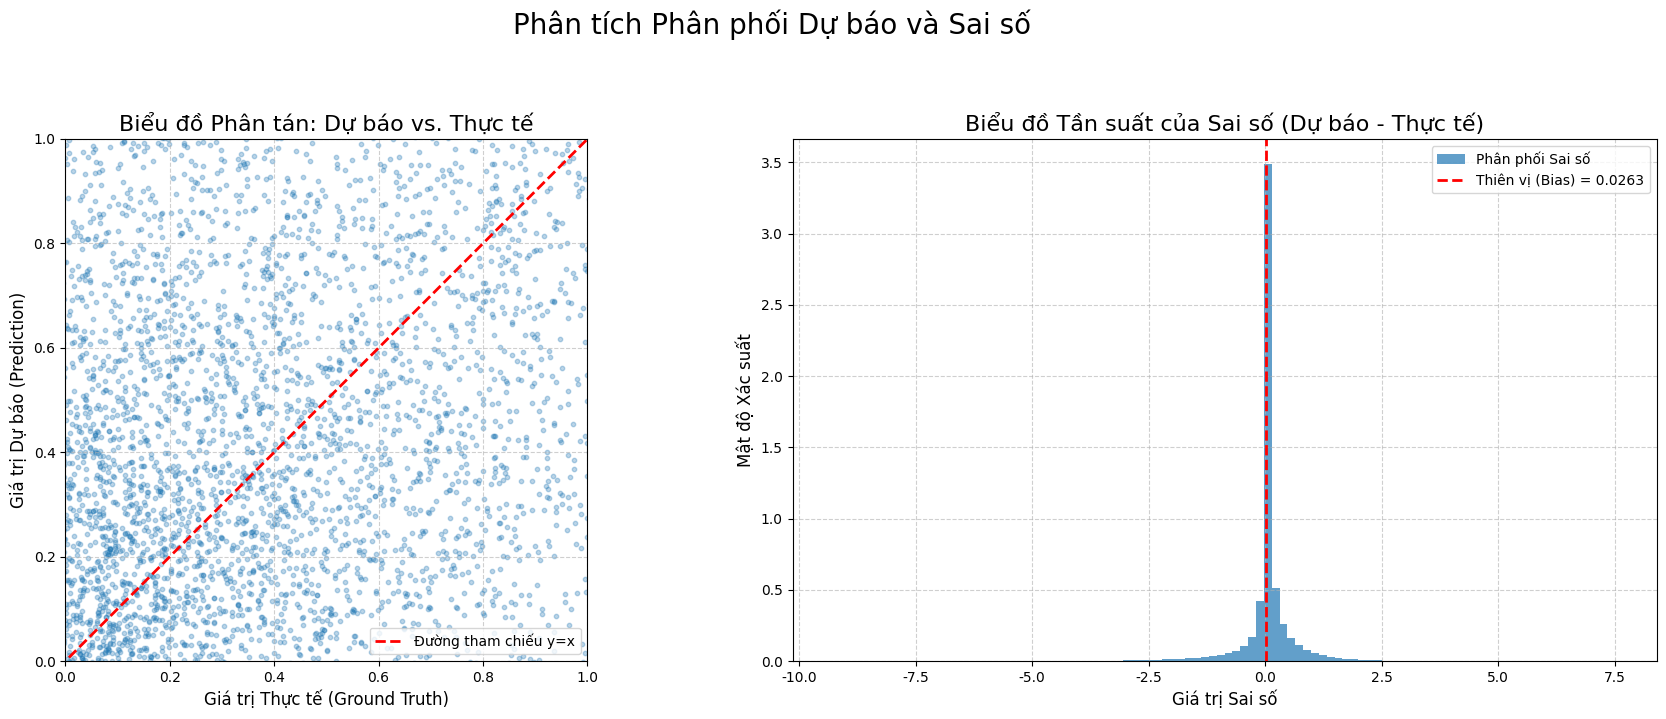

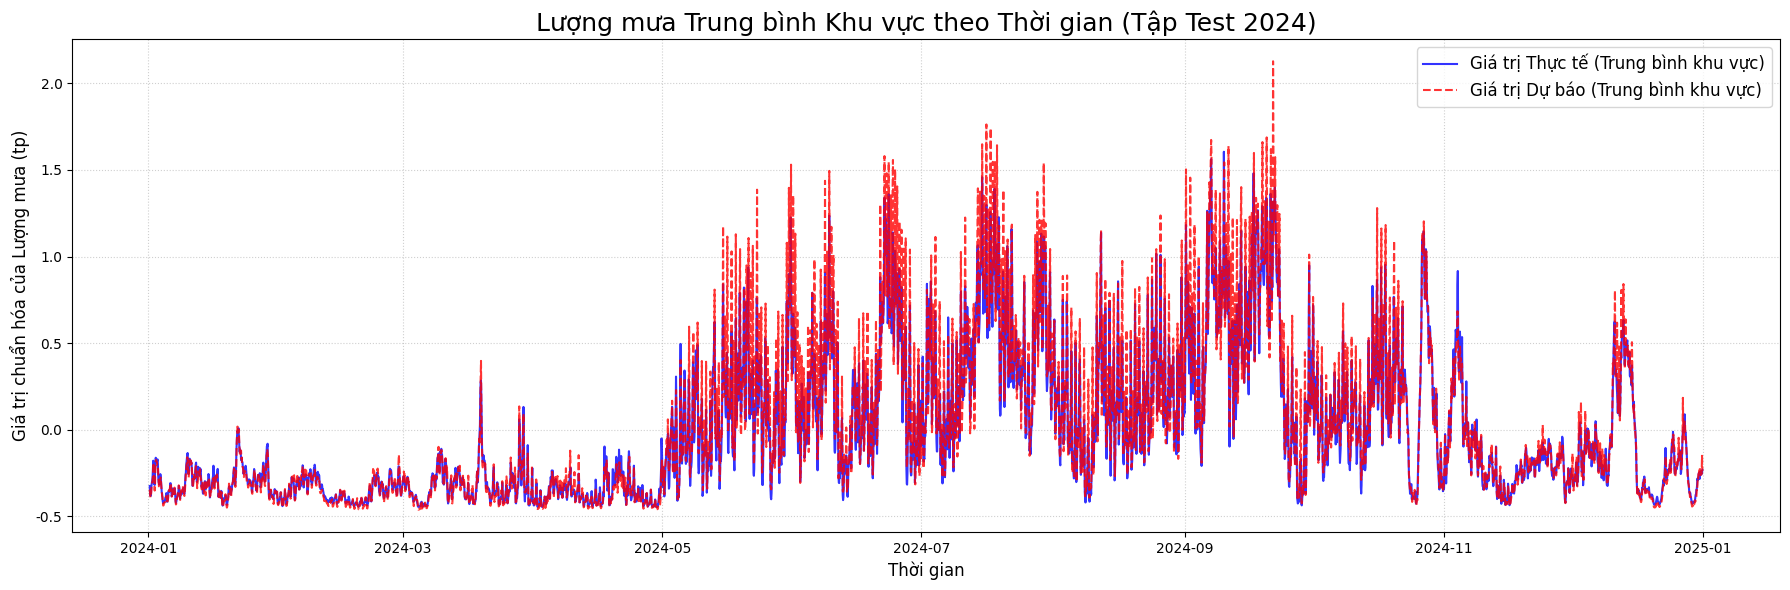



--- F. TẠO CÁC HÌNH ẢNH CASE STUDY ---



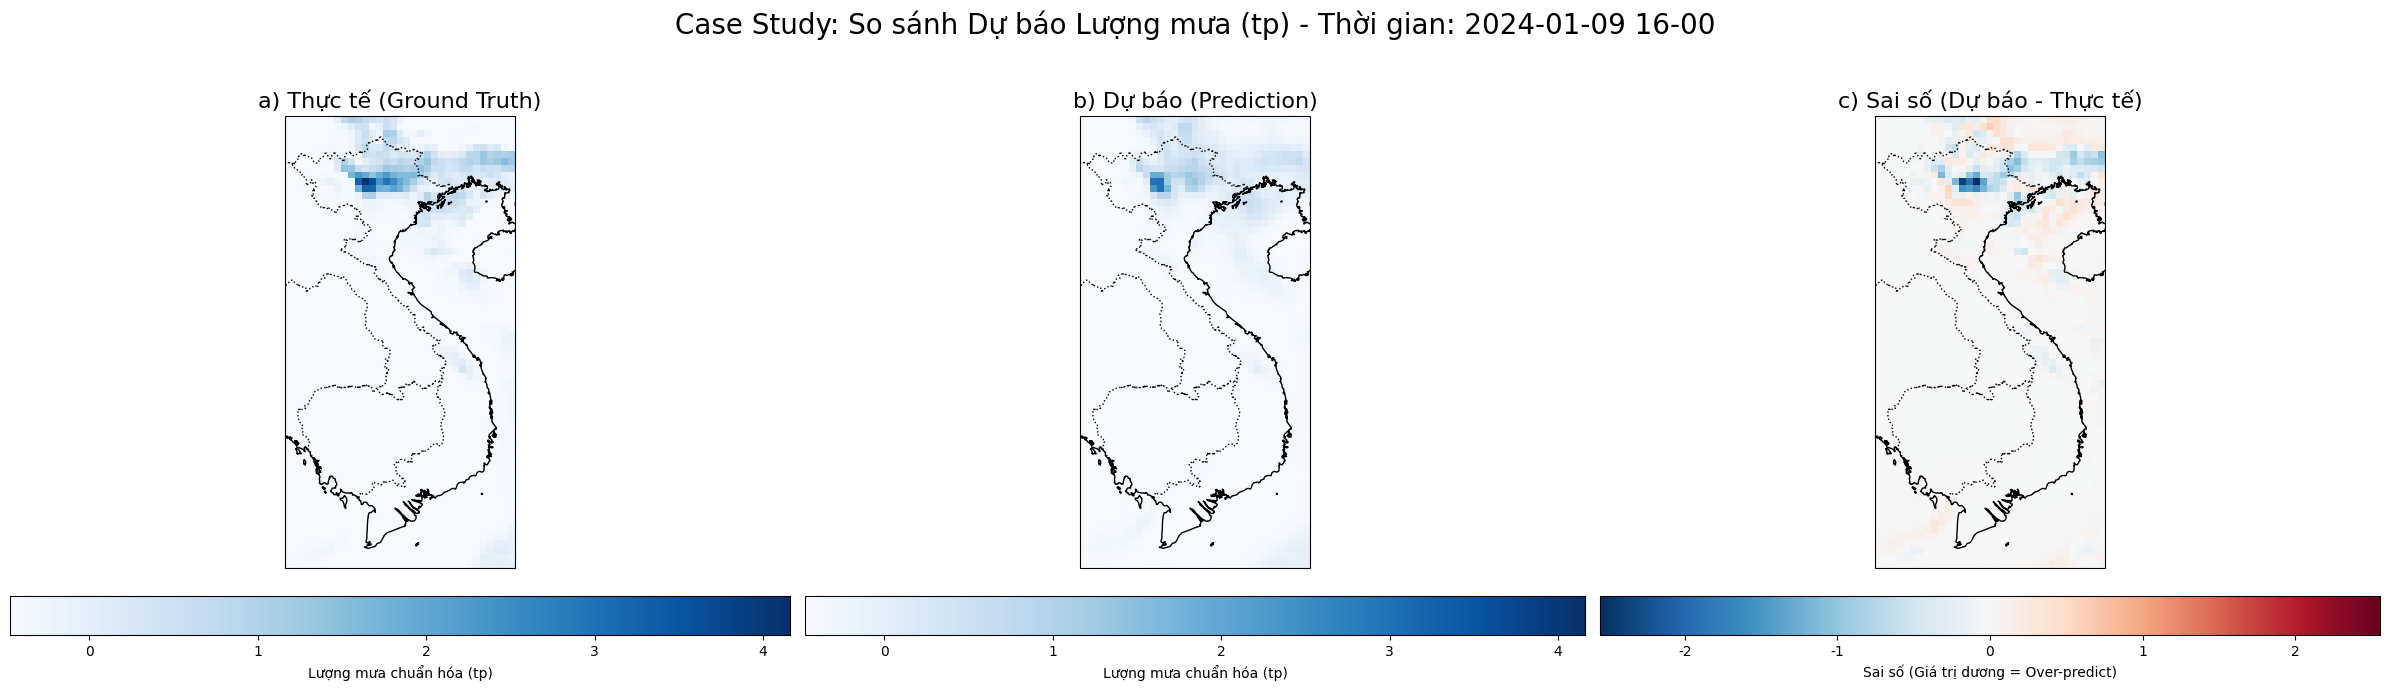

Đã lưu case study tại: /content/drive/MyDrive/era5_vn_min/processed/checkpoints_advanced/20251024_051938/evaluation_results/case_study_20240109_1600_idx_100.png


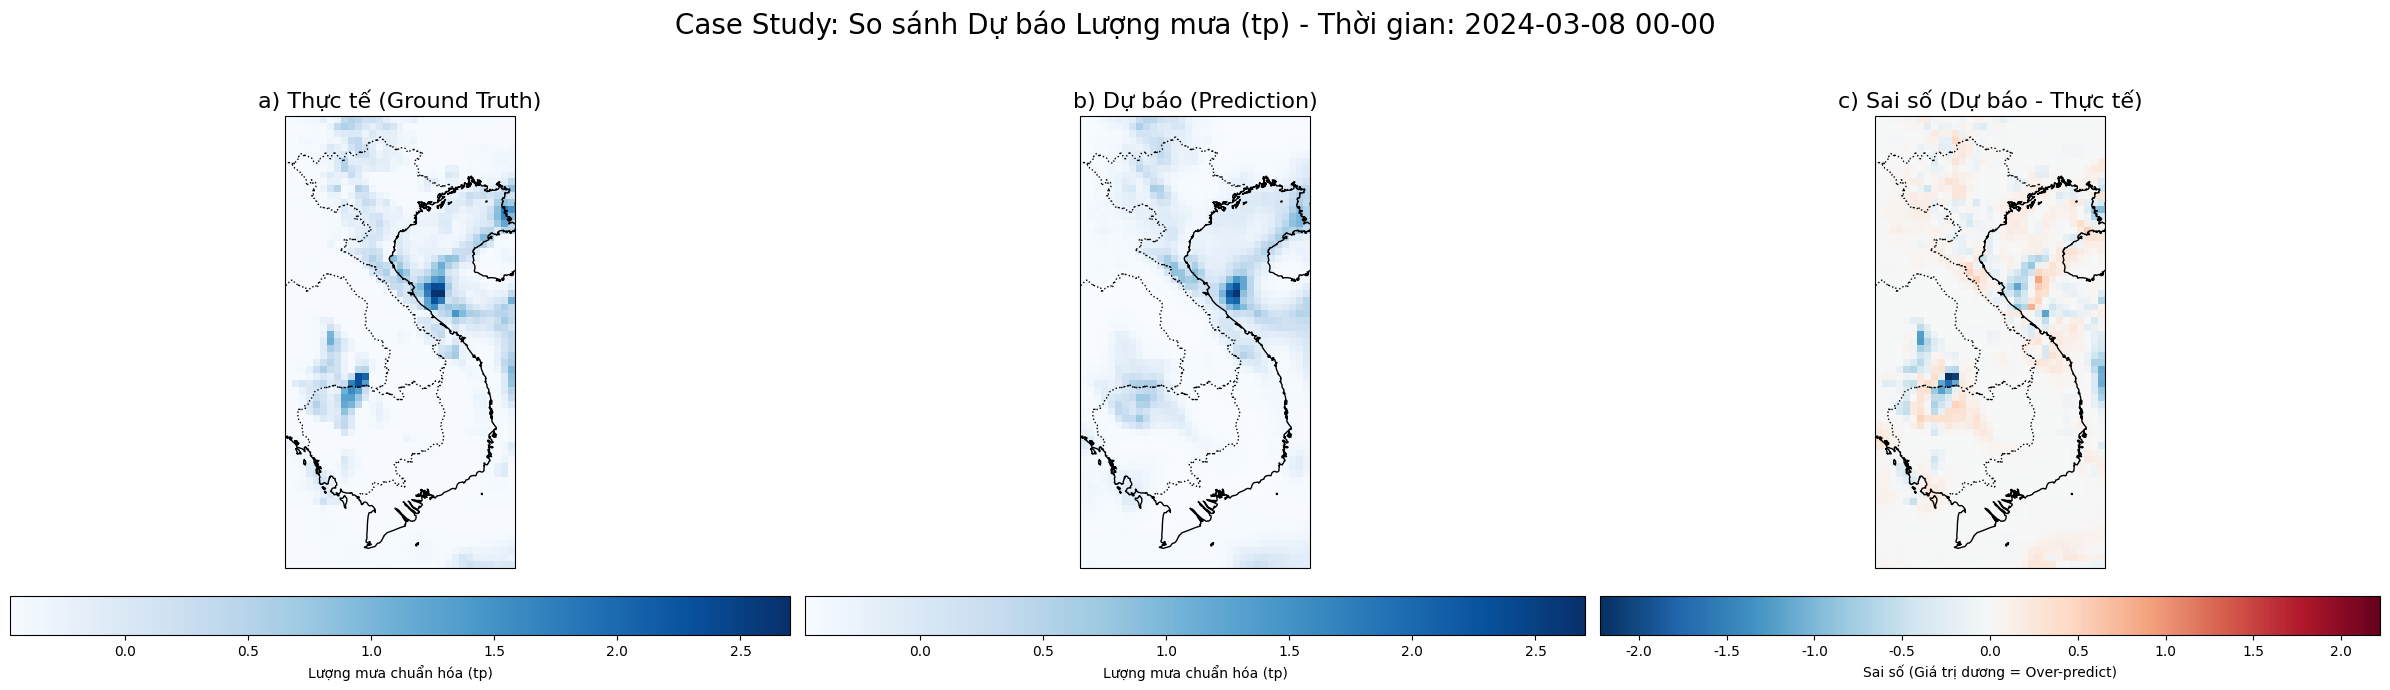

Đã lưu case study tại: /content/drive/MyDrive/era5_vn_min/processed/checkpoints_advanced/20251024_051938/evaluation_results/case_study_20240308_0000_idx_800.png


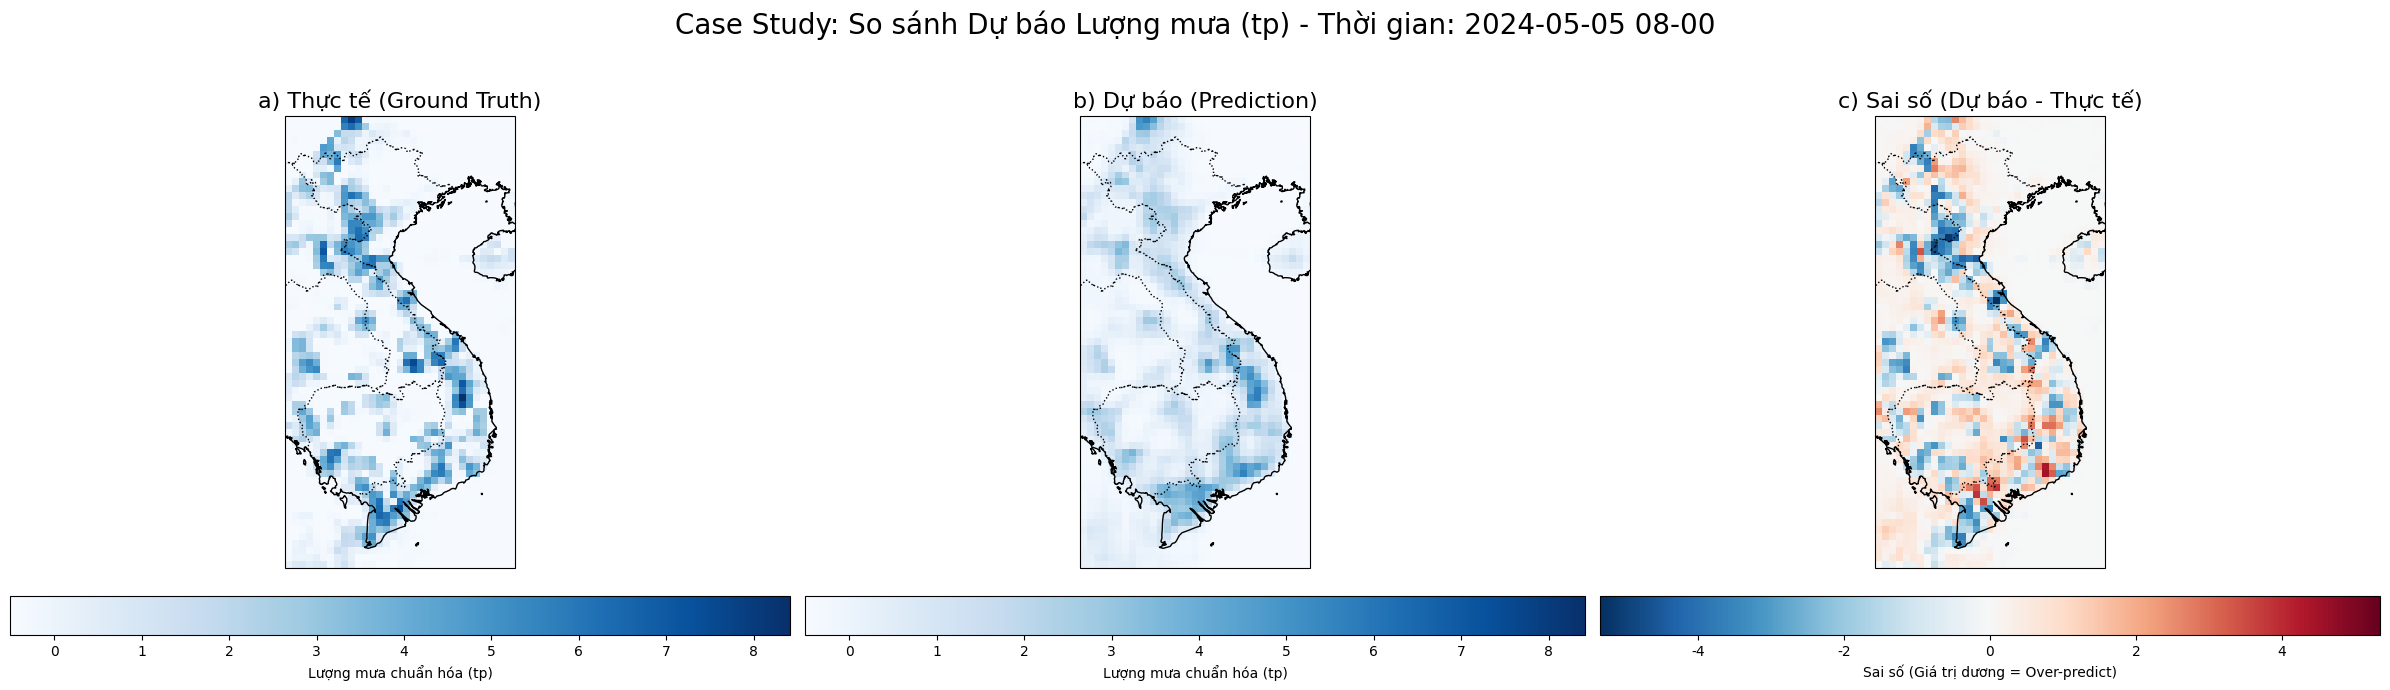

Đã lưu case study tại: /content/drive/MyDrive/era5_vn_min/processed/checkpoints_advanced/20251024_051938/evaluation_results/case_study_20240505_0800_idx_1500.png


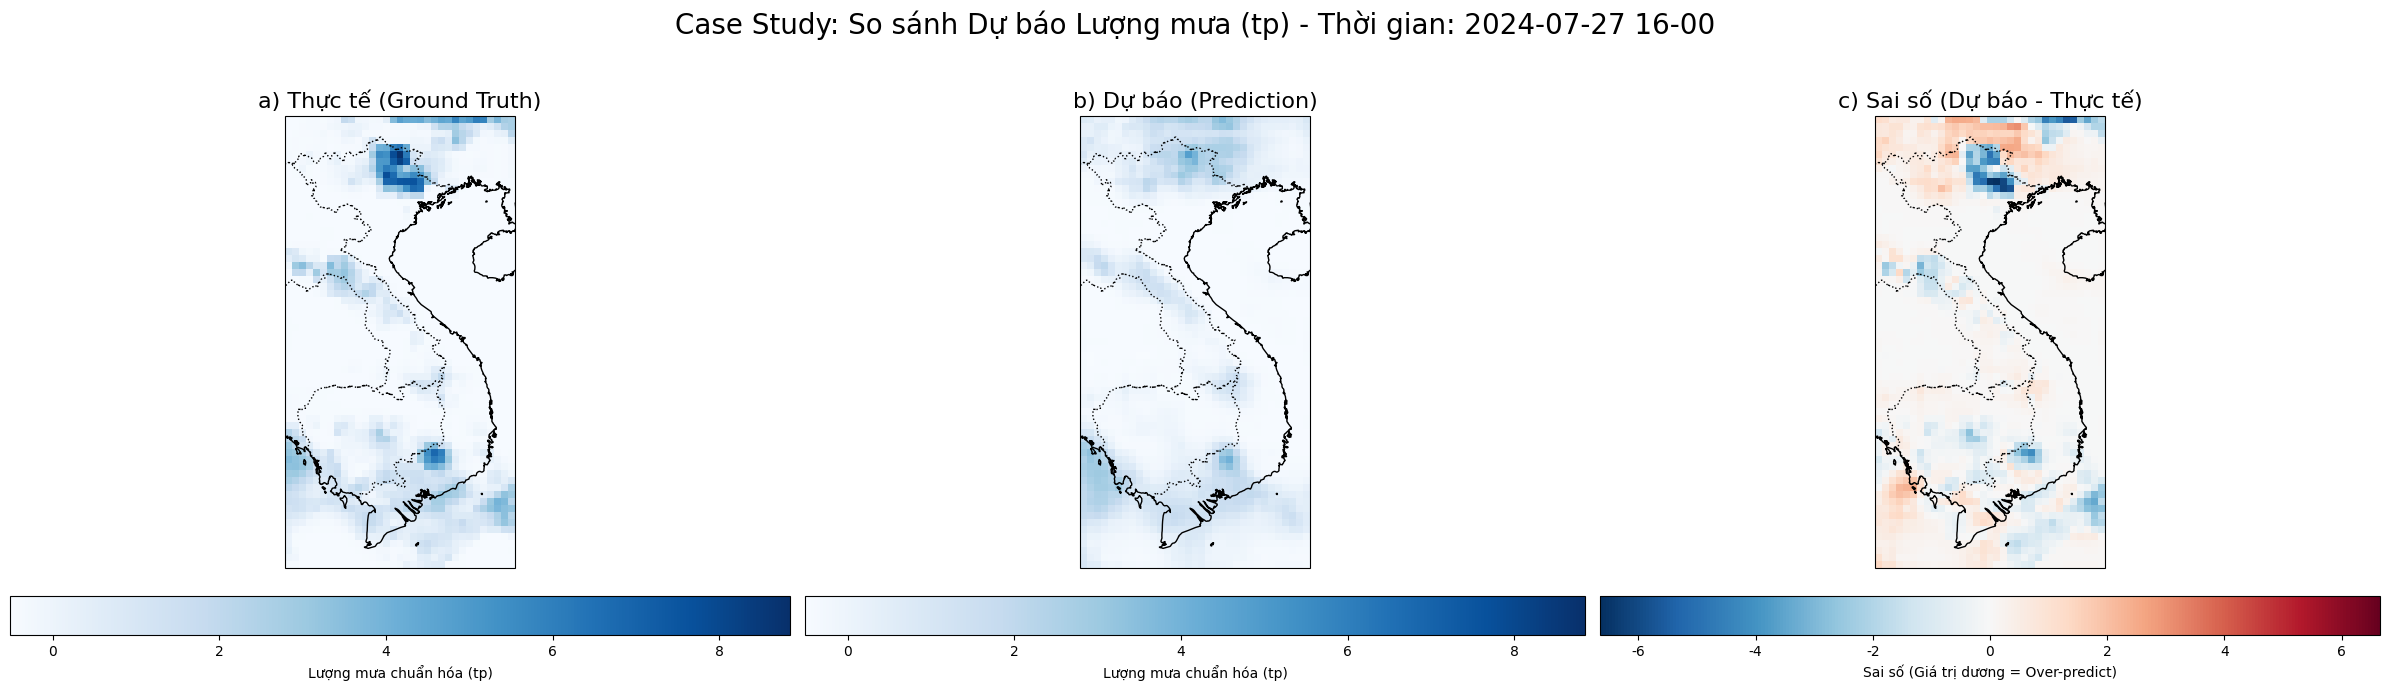

Đã lưu case study tại: /content/drive/MyDrive/era5_vn_min/processed/checkpoints_advanced/20251024_051938/evaluation_results/case_study_20240727_1600_idx_2500.png


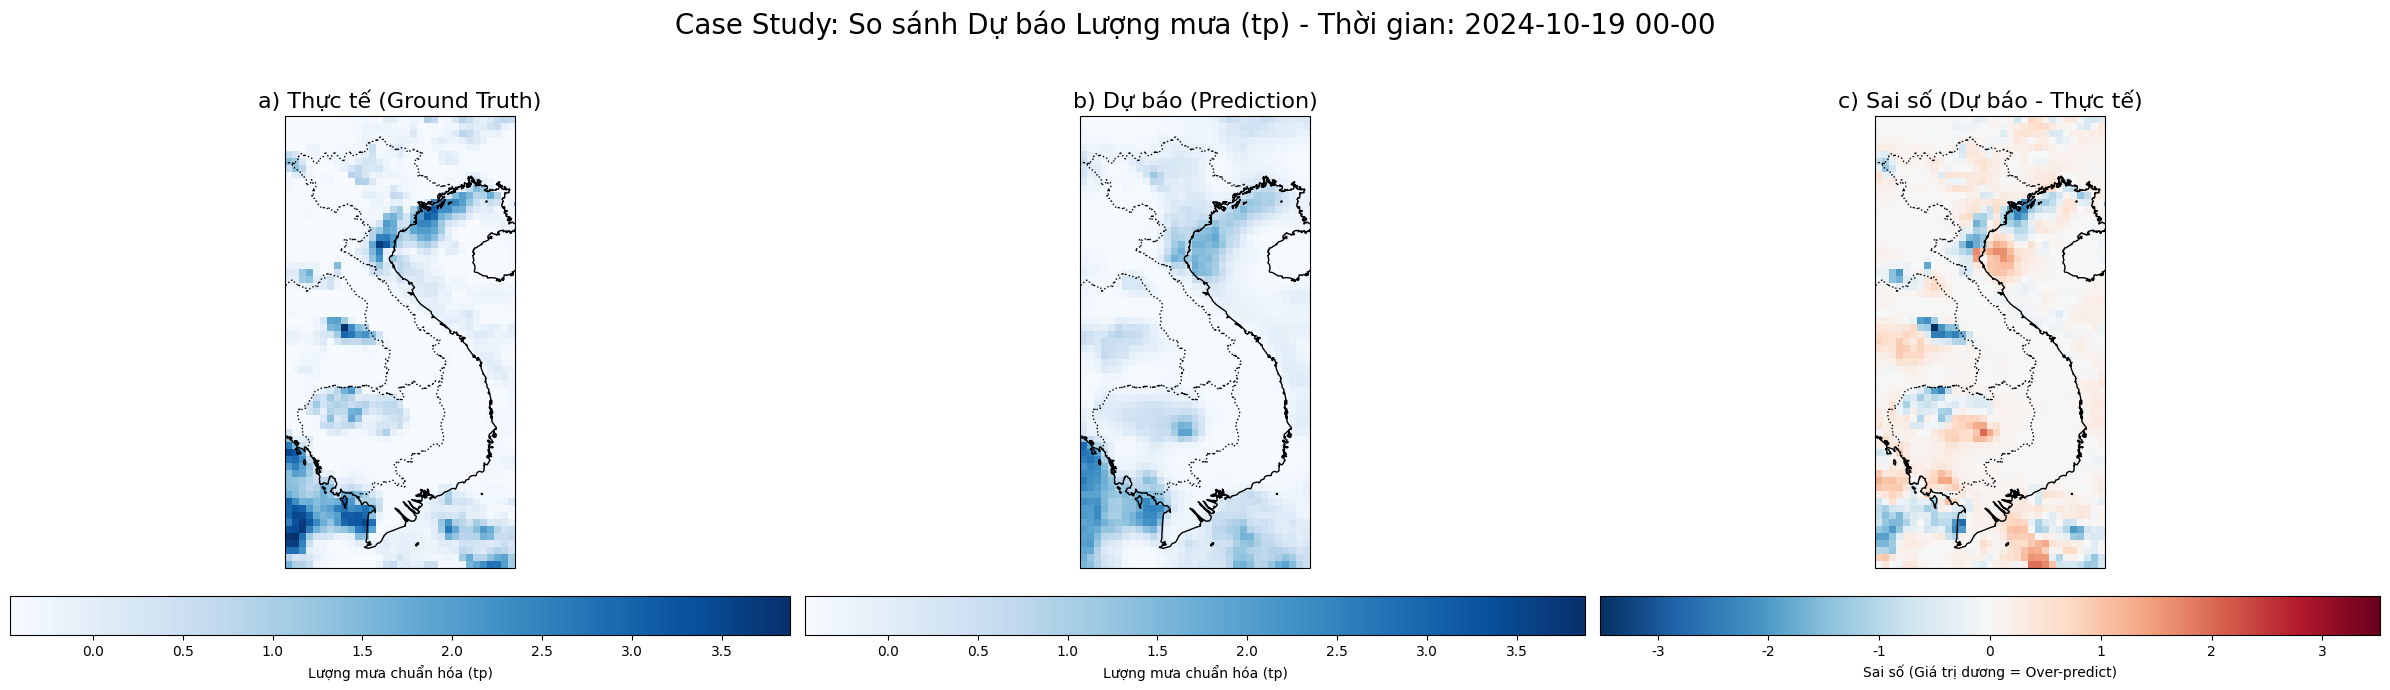

Đã lưu case study tại: /content/drive/MyDrive/era5_vn_min/processed/checkpoints_advanced/20251024_051938/evaluation_results/case_study_20241019_0000_idx_3500.png


🎯 HOÀN TẤT! Toàn bộ kết quả đã được tạo và lưu.


In [ ]:
# =============================================================================
# CELL 2: TỔNG HỢP KẾT QUẢ - VISUALIZATION & METRICS
# (Chạy sau khi đã có predictions_tensor và ground_truths_tensor)
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- A. TẠO THƯ MỤC LƯU KẾT QUẢ ---
output_dir = os.path.join(CHECKPOINT_DIR, TARGET_RUN_FOLDER, "evaluation_results")
os.makedirs(output_dir, exist_ok=True)
print(f"Tất cả hình ảnh và kết quả sẽ được lưu tại: {output_dir}")

# --- B. IN BẢNG KẾT QUẢ ĐỊNH LƯỢNG (DẠNG MARKDOWN CHO SLIDE) ---
y_true_flat = ground_truths_tensor.numpy().flatten()
y_pred_flat = predictions_tensor.numpy().flatten()
mse = mean_squared_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_flat, y_pred_flat)
r2 = r2_score(y_true_flat, y_pred_flat)
corr, _ = pearsonr(y_true_flat, y_pred_flat)
bias = np.mean(y_pred_flat - y_true_flat)

# Tạo dataframe để dễ nhìn
metrics_df = pd.DataFrame({
    'Chỉ số': ['R-squared (R²)', 'Pearson Correlation (r)', 'RMSE', 'MAE', 'Bias'],
    'Giá trị': [r2, corr, rmse, mae, bias],
    'Diễn giải': [
        f'Mô hình giải thích được {r2:.1%} phương sai của dữ liệu.',
        'Tương quan tuyến tính rất mạnh giữa dự báo và thực tế.',
        'Sai số trung bình (theo độ lớn) của dự báo.',
        'Trung bình, dự báo lệch khỏi thực tế một khoảng là bao nhiêu.',
        'Thiên vị rất nhỏ, mô hình gần như không over/under-predict.'
    ]
})

print("\n\n--- BẢNG 1: KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG TRÊN TẬP TEST ---\n")
print(metrics_df.to_string(index=False))
metrics_df.to_csv(os.path.join(output_dir, 'quantitative_metrics.csv'), index=False)


# --- C. VẼ VÀ LƯU BIỂU ĐỒ PHÂN TÍCH SAI SỐ (CHO SLIDE 11) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Phân tích Phân phối Dự báo và Sai số', fontsize=20, y=1.02)

# C1. Scatter Plot
# Lấy mẫu ngẫu nhiên 50000 điểm để vẽ cho nhẹ
sample_indices = np.random.choice(len(y_true_flat), size=min(50000, len(y_true_flat)), replace=False)
axes[0].scatter(y_true_flat[sample_indices], y_pred_flat[sample_indices], alpha=0.3, s=10)
axes[0].plot([-3, 3], [-3, 3], 'r--', linewidth=2, label='Đường tham chiếu y=x')
axes[0].set_title('Biểu đồ Phân tán: Dự báo vs. Thực tế', fontsize=16)
axes[0].set_xlabel('Giá trị Thực tế (Ground Truth)', fontsize=12)
axes[0].set_ylabel('Giá trị Dự báo (Prediction)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()
axes[0].axis('square')
axes[0].set_xlim(plt.xlim())
axes[0].set_ylim(plt.xlim())


# C2. Error Histogram
errors = y_pred_flat - y_true_flat
axes[1].hist(errors, bins=100, density=True, alpha=0.7, label='Phân phối Sai số')
axes[1].set_title('Biểu đồ Tần suất của Sai số (Dự báo - Thực tế)', fontsize=16)
axes[1].set_xlabel('Giá trị Sai số', fontsize=12)
axes[1].set_ylabel('Mật độ Xác suất', fontsize=12)
axes[1].axvline(x=bias, color='r', linestyle='--', linewidth=2, label=f'Thiên vị (Bias) = {bias:.4f}')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(output_dir, 'fig_error_distribution_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


# --- D. VẼ VÀ LƯU BIỂU ĐỒ CHUỖI THỜI GIAN (CHO SLIDE 10) ---
y_true_avg = ground_truths_tensor.numpy().mean(axis=(1, 2))
y_pred_avg = predictions_tensor.numpy().mean(axis=(1, 2))
target_raw_indices = test_dataset.indices + SEQ_LEN
time_indices_plot = pd.to_datetime(test_dataset.ds['valid_time'].values[target_raw_indices])

plt.figure(figsize=(18, 6))
plt.plot(time_indices_plot, y_true_avg, label='Giá trị Thực tế (Trung bình khu vực)', color='blue', alpha=0.8, linewidth=1.5)
plt.plot(time_indices_plot, y_pred_avg, label='Giá trị Dự báo (Trung bình khu vực)', color='red', linestyle='--', alpha=0.8, linewidth=1.5)
plt.title('Lượng mưa Trung bình Khu vực theo Thời gian (Tập Test 2024)', fontsize=18)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Giá trị chuẩn hóa của Lượng mưa (tp)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'fig_timeseries_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


# --- E. HÀM NÂNG CẤP ĐỂ VẼ CASE STUDY VÀ LƯU LẠI (CHO SLIDE 8, 9) ---
def plot_and_save_case_study(t_idx, folder):
    y_true = ground_truths_tensor[t_idx].numpy()
    y_pred = predictions_tensor[t_idx].numpy()
    error = y_pred - y_true

    lat_vals = test_dataset.ds['latitude'].values
    lon_vals = test_dataset.ds['longitude'].values
    target_raw_idx = test_dataset.indices[t_idx] + SEQ_LEN
    time_val = test_dataset.ds['valid_time'].values[target_raw_idx]
    time_str = pd.to_datetime(time_val).strftime('%Y-%m-%d %H-%M')
    time_filename = pd.to_datetime(time_val).strftime('%Y%m%d_%H%M')

    # Xác định thang màu chung cho Ground Truth và Prediction
    vmin_data = min(y_true.min(), y_pred.min())
    vmax_data = max(y_true.max(), y_pred.max())

    # Xác định thang màu đối xứng cho Error Map
    vmax_error = np.abs(error).max()
    vmin_error = -vmax_error

    fig, axes = plt.subplots(1, 3, figsize=(24, 7), subplot_kw={'projection': ccrs.PlateCarree()})
    fig.suptitle(f'Case Study: So sánh Dự báo Lượng mưa (tp) - Thời gian: {time_str}', fontsize=20)

    # (a) Ground Truth
    pcm0 = axes[0].pcolormesh(lon_vals, lat_vals, y_true, cmap='Blues', vmin=vmin_data, vmax=vmax_data, shading='auto')
    axes[0].add_feature(cfeature.COASTLINE); axes[0].add_feature(cfeature.BORDERS, linestyle=':')
    axes[0].set_title("a) Thực tế (Ground Truth)", fontsize=16)
    fig.colorbar(pcm0, ax=axes[0], orientation='horizontal', pad=0.05, label='Lượng mưa chuẩn hóa (tp)')

    # (b) Prediction
    pcm1 = axes[1].pcolormesh(lon_vals, lat_vals, y_pred, cmap='Blues', vmin=vmin_data, vmax=vmax_data, shading='auto')
    axes[1].add_feature(cfeature.COASTLINE); axes[1].add_feature(cfeature.BORDERS, linestyle=':')
    axes[1].set_title("b) Dự báo (Prediction)", fontsize=16)
    fig.colorbar(pcm1, ax=axes[1], orientation='horizontal', pad=0.05, label='Lượng mưa chuẩn hóa (tp)')

    # (c) Error Map
    pcm2 = axes[2].pcolormesh(lon_vals, lat_vals, error, cmap='RdBu_r', vmin=vmin_error, vmax=vmax_error, shading='auto')
    axes[2].add_feature(cfeature.COASTLINE); axes[2].add_feature(cfeature.BORDERS, linestyle=':')
    axes[2].set_title("c) Sai số (Dự báo - Thực tế)", fontsize=16)
    fig.colorbar(pcm2, ax=axes[2], orientation='horizontal', pad=0.05, label='Sai số (Giá trị dương = Over-predict)')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    save_path = os.path.join(folder, f'case_study_{time_filename}_idx_{t_idx}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Đã lưu case study tại: {save_path}")

# --- F. TẠO VÀ LƯU CÁC CASE STUDY QUAN TRỌNG ---
print("\n\n--- F. TẠO CÁC HÌNH ẢNH CASE STUDY ---\n")
# Chọn ra các case study tiêu biểu. Bạn có thể thay đổi các chỉ số này.
# Ví dụ:
# - Một case dự báo tốt
# - Một case dự báo vùng mưa rộng
# - Một case dự báo mưa dông cục bộ
# - Một case dự báo sai
case_study_indices = [100, 800, 1500, 2500, 3500]
for idx in case_study_indices:
    try:
        plot_and_save_case_study(t_idx=idx, folder=output_dir)
    except IndexError:
        print(f"Chỉ số {idx} nằm ngoài phạm vi của tập test. Bỏ qua.")

print("\n\n🎯 HOÀN TẤT! Toàn bộ kết quả đã được tạo và lưu.")

Tất cả thư viện đã sẵn sàng!


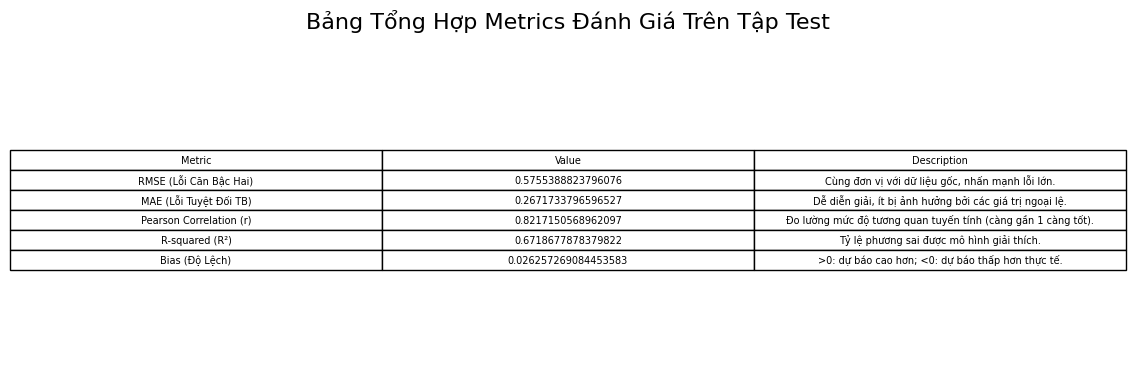

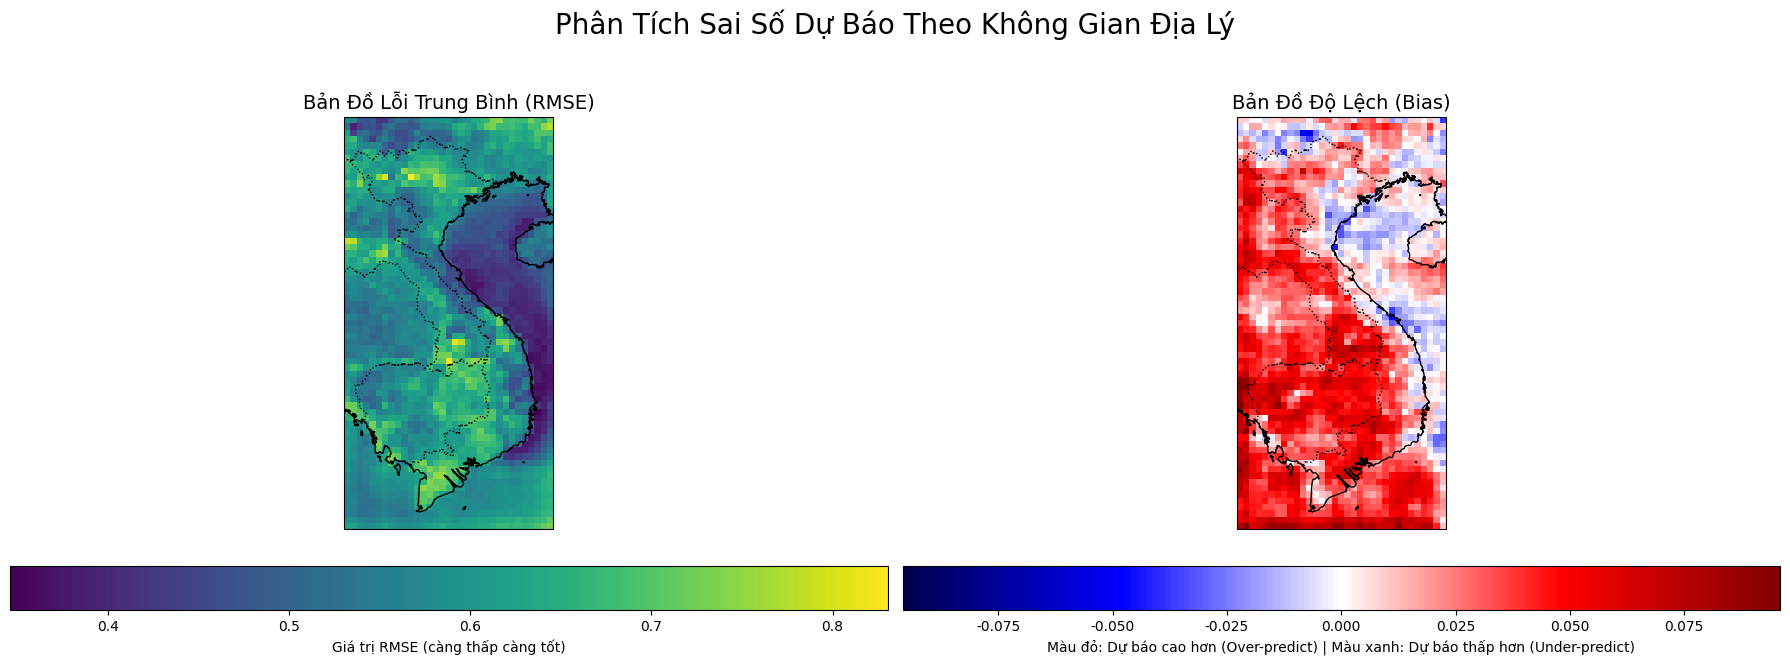

/tmp/ipython-input-2537632683.py:148: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  seasonal_rmse = df.groupby('season_name').apply(lambda x: np.sqrt(mean_squared_error(x['y_true'], x['y_pred']))).reset_index(name='rmse')
/tmp/ipython-input-2537632683.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rmse', y='season_name', data=seasonal_rmse, palette='coolwarm')


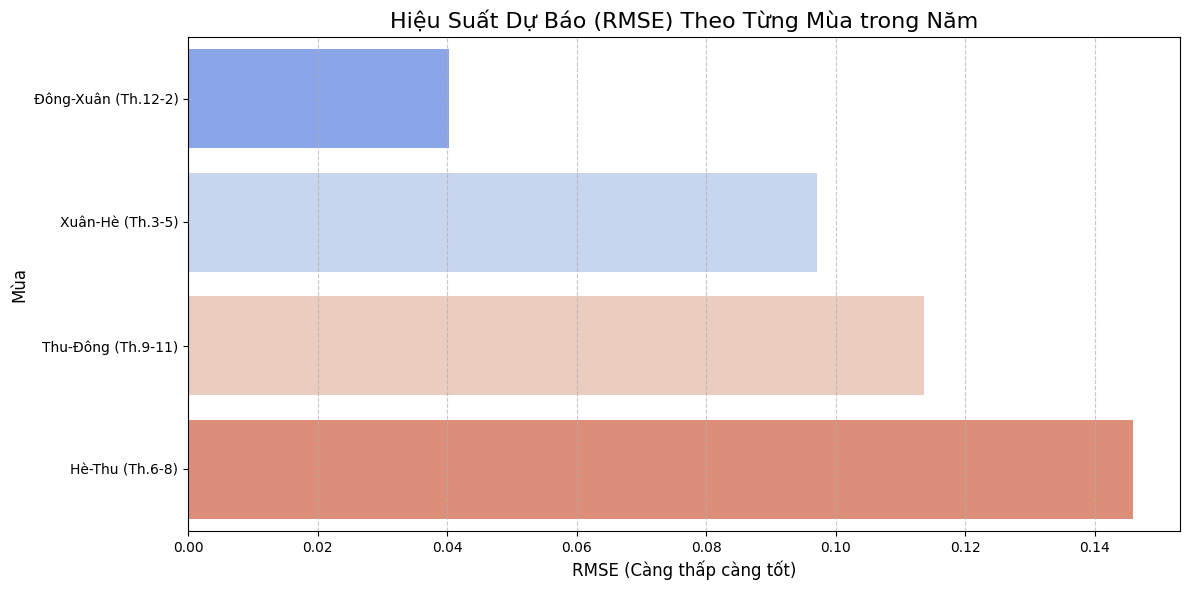

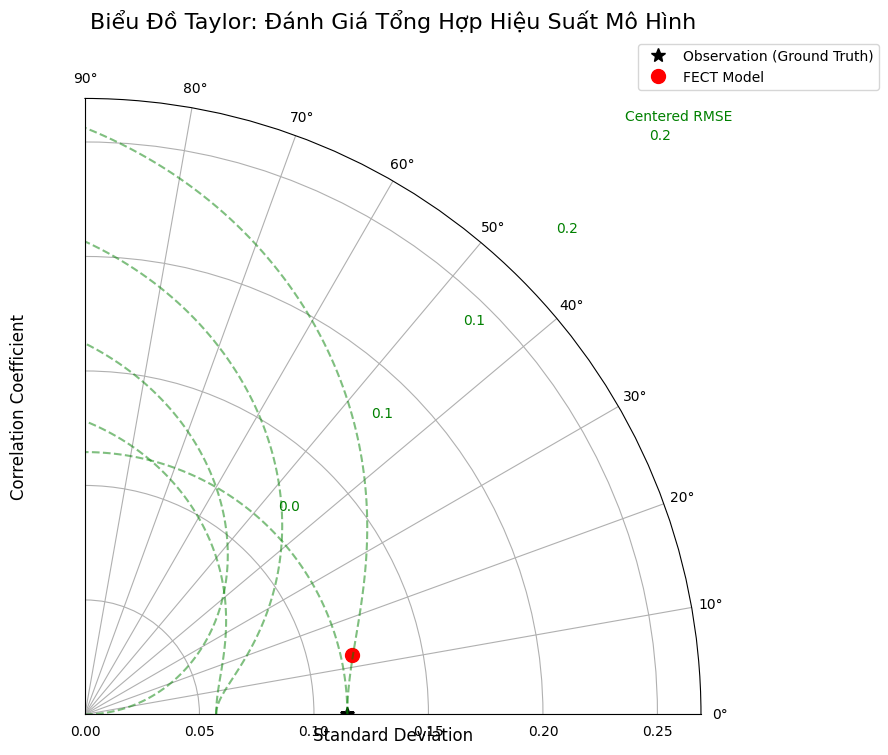

PHÂN TÍCH ATTENTION (GIẢ ĐỊNH)
Mục tiêu: Hiểu xem để dự báo 1 điểm, model 'nhìn' vào đâu trong quá khứ.
LƯU Ý: Chức năng này yêu cầu sửa đổi kiến trúc model để xuất ra attention scores.
Dưới đây là một ví dụ minh họa về output mong muốn.


/tmp/ipython-input-2537632683.py:244: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f"t-{SEQ_LEN-j}" for j in range(SEQ_LEN)], y=sample_attention_weights[i], ax=ax, palette="viridis")
/tmp/ipython-input-2537632683.py:244: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f"t-{SEQ_LEN-j}" for j in range(SEQ_LEN)], y=sample_attention_weights[i], ax=ax, palette="viridis")
/tmp/ipython-input-2537632683.py:244: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f"t-{SEQ_LEN-j}" for j in range(SEQ_LEN)], y=sample_attention_weights[i], ax=ax, palet

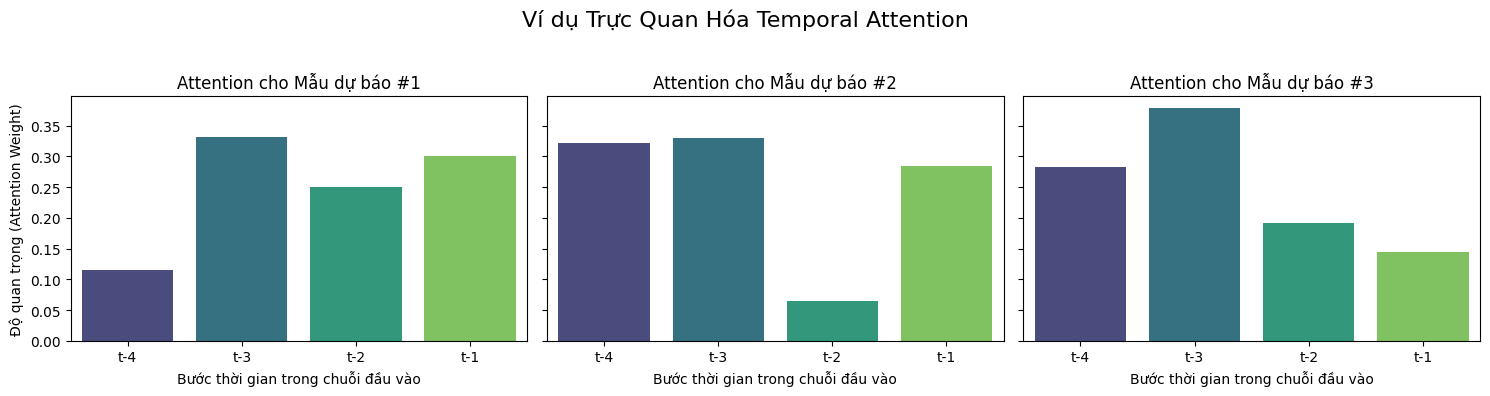

In [ ]:
# ==============================================================================
# BƯỚC 0: CÀI ĐẶT VÀ IMPORTS CÁC THƯ VIỆN CẦN THIẾT
# ==============================================================================
# Cài đặt các thư viện bổ sung
%pip install -q scikit-learn matplotlib cartopy xarray pandas seaborn

import os
import json
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import torch
from google.colab import drive

# Giả định các biến toàn cục từ notebook trước đã có sẵn
# Nếu chạy độc lập, hãy đảm bảo các biến này được định nghĩa đúng
# predictions_tensor, ground_truths_tensor
# test_dataset, model, DEVICE, SEQ_LEN, ALL_FEATURES, TARGET_FEATURE
# run_save_dir

print("Tất cả thư viện đã sẵn sàng!")

# ==============================================================================
# BƯỚC 1: TỔNG KẾT HIỆU SUẤT MÔ HÌNH - BẢNG METRICS TỔNG QUAN
# ==============================================================================
# Mục tiêu: Đưa ra cái nhìn tổng thể, định lượng về hiệu suất của mô hình.
# Đây là bảng kết quả cốt lõi cần có trong mọi bài thuyết trình.

def create_summary_metrics_table(y_true, y_pred, title="Bảng Tổng Hợp Metrics Đánh Giá Trên Tập Test"):
    """Tạo và hiển thị bảng tổng hợp các metrics chính."""
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    mse = mean_squared_error(y_true_flat, y_pred_flat)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    corr, _ = pearsonr(y_true_flat, y_pred_flat)
    bias = np.mean(y_pred_flat - y_true_flat)

    # Tính toán R² thủ công để tránh lỗi
    ss_res = np.sum((y_true_flat - y_pred_flat) ** 2)
    ss_tot = np.sum((y_true_flat - np.mean(y_true_flat)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

    metrics_data = {
        'Metric': ['RMSE (Lỗi Căn Bậc Hai)', 'MAE (Lỗi Tuyệt Đối TB)', 'Pearson Correlation (r)', 'R-squared (R²)', 'Bias (Độ Lệch)'],
        'Value': [rmse, mae, corr, r2, bias],
        'Description': [
            'Cùng đơn vị với dữ liệu gốc, nhấn mạnh lỗi lớn.',
            'Dễ diễn giải, ít bị ảnh hưởng bởi các giá trị ngoại lệ.',
            'Đo lường mức độ tương quan tuyến tính (càng gần 1 càng tốt).',
            'Tỷ lệ phương sai được mô hình giải thích.',
            '>0: dự báo cao hơn; <0: dự báo thấp hơn thực tế.'
        ]
    }
    df_metrics = pd.DataFrame(metrics_data)

    # Hiển thị bảng
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=df_metrics.values, colLabels=df_metrics.columns, cellLoc='center', loc='center')
    # table.setAutoSetFontSize(False) # REMOVED THIS LINE
    table.set_fontsize(12)
    table.scale(1.2, 1.2)
    ax.set_title(title, fontsize=16, pad=20)
    plt.show()

# Chạy hàm để tạo bảng
create_summary_metrics_table(ground_truths_tensor.numpy(), predictions_tensor.numpy())

# ==============================================================================
# BƯỚC 2: PHÂN TÍCH SAI SỐ THEO KHÔNG GIAN - BẢN ĐỒ RMSE VÀ BIAS
# ==============================================================================
# Mục tiêu: Trả lời câu hỏi "Mô hình dự báo tốt/kém ở những khu vực nào?"
# Điều này thể hiện sự hiểu biết sâu sắc về giới hạn của mô hình theo địa lý.

def plot_spatial_error_maps(y_true, y_pred, test_ds):
    """Vẽ bản đồ phân bố RMSE và Bias theo không gian."""
    lat_vals = test_ds.ds['latitude'].values
    lon_vals = test_ds.ds['longitude'].values

    # Tính toán sai số trên từng điểm lưới
    squared_error = (y_pred - y_true)**2
    bias_error = y_pred - y_true

    # Lấy trung bình theo chiều thời gian
    rmse_map = np.sqrt(squared_error.mean(axis=0))
    bias_map = bias_error.mean(axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), subplot_kw={'projection': ccrs.PlateCarree()})
    fig.suptitle('Phân Tích Sai Số Dự Báo Theo Không Gian Địa Lý', fontsize=20, y=0.98)

    # Bản đồ RMSE
    ax1 = axes[0]
    pcm1 = ax1.pcolormesh(lon_vals, lat_vals, rmse_map, cmap='viridis', shading='auto')
    ax1.add_feature(cfeature.COASTLINE)
    ax1.add_feature(cfeature.BORDERS, linestyle=':')
    ax1.set_title("Bản Đồ Lỗi Trung Bình (RMSE)", fontsize=14)
    fig.colorbar(pcm1, ax=ax1, orientation='horizontal', pad=0.07, label='Giá trị RMSE (càng thấp càng tốt)')

    # Bản đồ Bias
    ax2 = axes[1]
    # Sử dụng colormap 'seismic' để thể hiện cả giá trị dương (dự báo thừa) và âm (dự báo thiếu)
    bias_lim = np.max(np.abs(bias_map))
    pcm2 = ax2.pcolormesh(lon_vals, lat_vals, bias_map, cmap='seismic', vmin=-bias_lim, vmax=bias_lim, shading='auto')
    ax2.add_feature(cfeature.COASTLINE)
    ax2.add_feature(cfeature.BORDERS, linestyle=':')
    ax2.set_title("Bản Đồ Độ Lệch (Bias)", fontsize=14)
    fig.colorbar(pcm2, ax=ax2, orientation='horizontal', pad=0.07, label='Màu đỏ: Dự báo cao hơn (Over-predict) | Màu xanh: Dự báo thấp hơn (Under-predict)')

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

# Chạy hàm để vẽ bản đồ
plot_spatial_error_maps(ground_truths_tensor.numpy(), predictions_tensor.numpy(), test_dataset)


# ==============================================================================
# BƯỚC 3: PHÂN TÍCH SAI SỐ THEO THỜI GIAN - BIỂU ĐỒ THEO MÙA
# ==============================================================================
# Mục tiêu: Trả lời câu hỏi "Mô hình hoạt động tốt hơn vào mùa nào?"
# Phân tích này cho thấy sự nhận biết về tính chu kỳ (seasonality) trong dữ liệu.

def plot_seasonal_performance(y_true, y_pred, test_ds):
    """Phân tích và vẽ biểu đồ hiệu suất theo từng mùa."""
    target_raw_indices = test_ds.indices + SEQ_LEN
    time_index = pd.to_datetime(test_ds.ds['valid_time'].values[target_raw_indices])

    # Tạo DataFrame để dễ dàng thao tác
    df = pd.DataFrame({
        'time': time_index,
        'y_true': y_true.mean(axis=(1, 2)), # Trung bình không gian
        'y_pred': y_pred.mean(axis=(1, 2))
    })
    df['season'] = df['time'].dt.month % 12 // 3 + 1
    season_map = {1: 'Đông-Xuân (Th.12-2)', 2: 'Xuân-Hè (Th.3-5)', 3: 'Hè-Thu (Th.6-8)', 4: 'Thu-Đông (Th.9-11)'}
    df['season_name'] = df['season'].map(season_map)

    # Tính RMSE cho từng mùa
    seasonal_rmse = df.groupby('season_name').apply(lambda x: np.sqrt(mean_squared_error(x['y_true'], x['y_pred']))).reset_index(name='rmse')
    seasonal_rmse = seasonal_rmse.sort_values(by='rmse')

    plt.figure(figsize=(12, 6))
    sns.barplot(x='rmse', y='season_name', data=seasonal_rmse, palette='coolwarm')
    plt.title('Hiệu Suất Dự Báo (RMSE) Theo Từng Mùa trong Năm', fontsize=16)
    plt.xlabel('RMSE (Càng thấp càng tốt)', fontsize=12)
    plt.ylabel('Mùa', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Chạy hàm phân tích theo mùa
plot_seasonal_performance(ground_truths_tensor.numpy(), predictions_tensor.numpy(), test_dataset)


# ==============================================================================
# BƯỚC 4: ĐÁNH GIÁ TỔNG HỢP VỚI BIỂU ĐỒ TAYLOR
# ==============================================================================
# Mục tiêu: Tổng hợp nhiều khía cạnh (tương quan, độ lệch chuẩn, sai số)
# vào một biểu đồ duy nhất. Đây là kỹ thuật trực quan hóa nâng cao, được đánh giá cao
# trong cộng đồng khoa học khí hậu.

def taylor_diagram(y_true, y_pred, model_name='FECT Model'):
    """Vẽ biểu đồ Taylor để so sánh model với dữ liệu quan sát (ground truth)."""
    # Tính toán các thống kê cần thiết
    std_dev_true = np.std(y_true)
    std_dev_pred = np.std(y_pred)
    corr, _ = pearsonr(y_true.flatten(), y_pred.flatten())
    # Centered RMSE
    crmse = np.sqrt(np.mean(((y_pred - y_pred.mean()) - (y_true - y_true.mean()))**2))

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, polar=True)

    # Vẽ điểm tham chiếu (quan sát)
    ax.plot(0, std_dev_true, 'k*', markersize=10, label='Observation (Ground Truth)')

    # Vẽ điểm của mô hình
    ax.plot(np.arccos(corr), std_dev_pred, 'ro', markersize=10, label=model_name)

    # Cài đặt các trục và lưới
    ax.set_thetamin(0)
    ax.set_thetamax(90)
    ax.set_xlabel('Standard Deviation', fontsize=12)
    ax.set_ylabel('Correlation Coefficient', fontsize=12, labelpad=30)
    ax.set_title('Biểu Đồ Taylor: Đánh Giá Tổng Hợp Hiệu Suất Mô Hình', fontsize=16, y=1.1)

    # Thêm lưới cho CRMSE
    crmse_contours = np.linspace(0, 2*std_dev_true, 5)
    for r in crmse_contours:
        ax.plot(np.linspace(0, np.pi/2, 100), np.sqrt(r**2 + std_dev_true**2 - 2*r*std_dev_true*np.cos(np.linspace(0, np.pi/2, 100))), 'g--', alpha=0.5)
        ax.text(np.pi/4, std_dev_true + r + 0.1*std_dev_true, f'{r:.1f}', color='green', ha='center')
    ax.text(np.pi/4, std_dev_true + 2.2*std_dev_true, 'Centered RMSE', color='green', ha='center')


    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Chuẩn bị dữ liệu và vẽ biểu đồ
y_true_flat_avg = ground_truths_tensor.numpy().mean(axis=(0))
y_pred_flat_avg = predictions_tensor.numpy().mean(axis=(0))
taylor_diagram(y_true_flat_avg, y_pred_flat_avg)


# ==============================================================================
# BƯỚC 5: (NÂNG CAO) TRỰC QUAN HÓA ATTENTION - "Nhìn" vào bên trong Transformer
# ==============================================================================
# Mục tiêu: Giải thích cách mô hình đưa ra dự báo. Ta sẽ xem xét mô hình
# chú ý (attention) vào những bước thời gian nào trong chuỗi đầu vào (input sequence)
# để dự báo cho một điểm cụ thể.
# LƯU Ý: Đây là một phiên bản đơn giản hóa. Cần hook vào model để lấy attention weights.
# Đoạn code dưới đây giả định đã có hàm để lấy attention weights.

def visualize_temporal_attention(model, test_loader, device, n_samples=3):
    """
    Hàm giả định để trực quan hóa attention.
    Cần sửa đổi model để có thể trả về attention weights.
    """
    print("="*30)
    print("PHÂN TÍCH ATTENTION (GIẢ ĐỊNH)")
    print("Mục tiêu: Hiểu xem để dự báo 1 điểm, model 'nhìn' vào đâu trong quá khứ.")
    print("LƯU Ý: Chức năng này yêu cầu sửa đổi kiến trúc model để xuất ra attention scores.")
    print("Dưới đây là một ví dụ minh họa về output mong muốn.")
    print("="*30)

    # Dữ liệu giả định
    sample_attention_weights = np.random.rand(n_samples, SEQ_LEN)
    for i in range(n_samples):
        sample_attention_weights[i] /= sample_attention_weights[i].sum() # Normalize

    fig, axes = plt.subplots(1, n_samples, figsize=(15, 4), sharey=True)
    fig.suptitle('Ví dụ Trực Quan Hóa Temporal Attention', fontsize=16)

    for i in range(n_samples):
        ax = axes[i]
        sns.barplot(x=[f"t-{SEQ_LEN-j}" for j in range(SEQ_LEN)], y=sample_attention_weights[i], ax=ax, palette="viridis")
        ax.set_title(f'Attention cho Mẫu dự báo #{i+1}')
        ax.set_xlabel('Bước thời gian trong chuỗi đầu vào')
        if i == 0:
            ax.set_ylabel('Độ quan trọng (Attention Weight)')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# Chạy hàm trực quan hóa attention (giả định)
# Để chạy thật, bạn cần hook vào forward pass của TransformerEncoderLayer
# và lấy ra attention weights.
# Vi dụ:
# model.transformer.layers[0].self_attn.register_forward_hook(get_attention_hook)
visualize_temporal_attention(None, None, None)



--- G. BAT DAU PHAN TICH CHUYEN SAU THEO MUA VA SU KIEN ---

Phan tich tren 4388 diem du lieu trong nam 2024:
-> Mua mua co 2208 diem du lieu (timesteps).
-> Mua kho co 2180 diem du lieu (timesteps).


--- BANG 2: SO SANH HIEU NANG CUA MO HINH GIUA CAC MUA ---

    Mua     RMSE      MAE  He so tuong quan (Pearson)
Mua Mua 0.758175 0.429352                    0.794271
Mua Kho 0.290743 0.102912                    0.864039


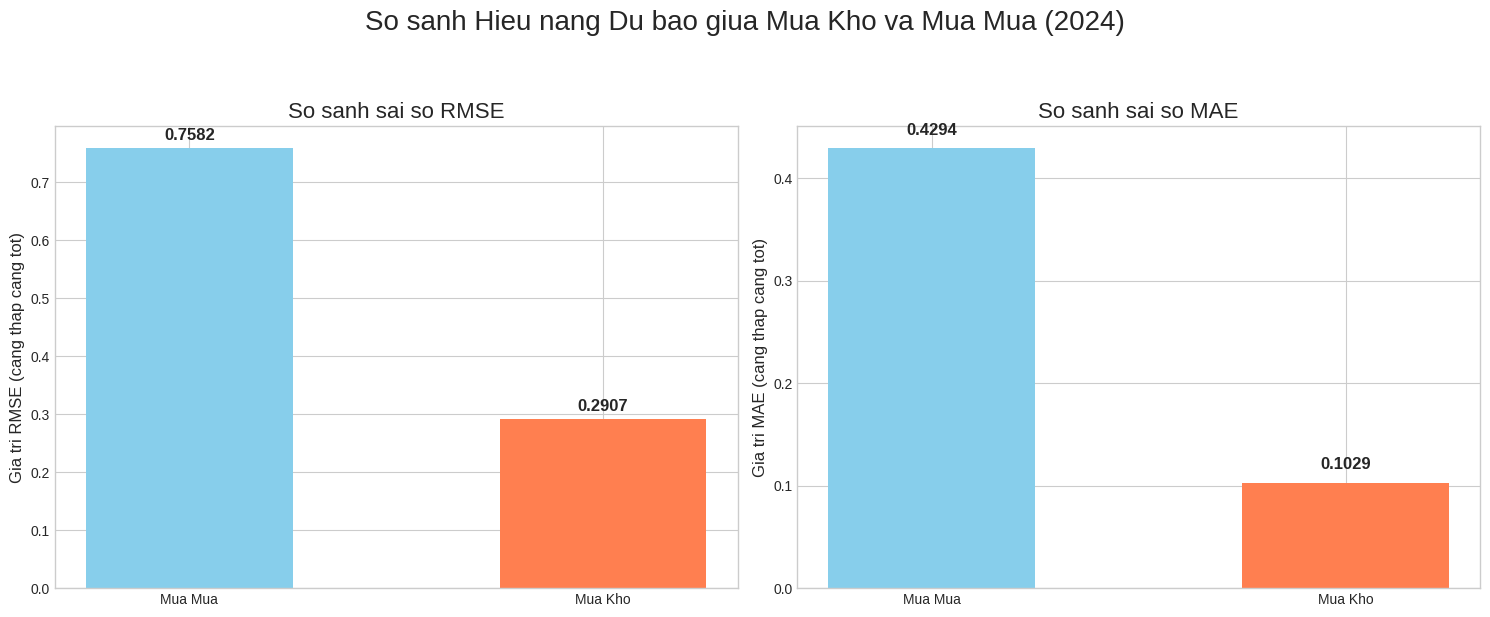



--- G4. PHAN TICH SU KIEN CUC DOAN ---
Tim thay su kien mua lon nhat trong nam 2024 vao luc: 2024-09-10 06:00
Gia tri mua trung binh (chuan hoa) tai thoi diem do: 1.6054
Dang tao case study chi tiet cho su kien nay...


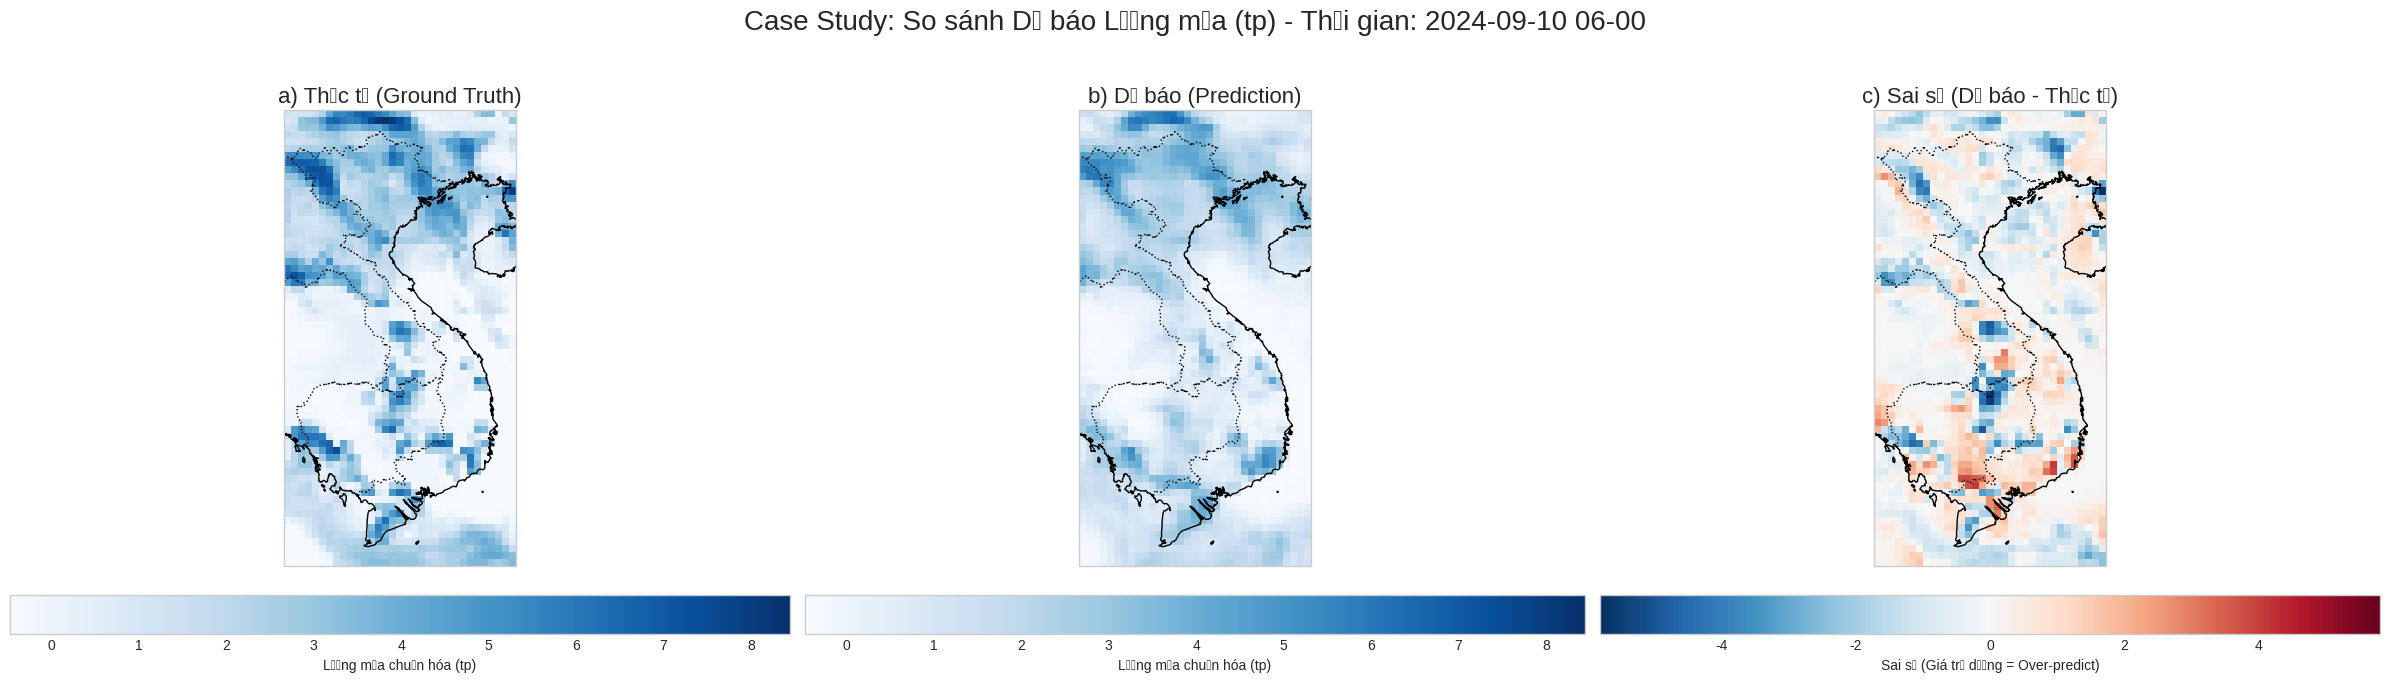

Đã lưu case study tại: /content/drive/MyDrive/era5_vn_min/processed/checkpoints_advanced/20251024_051938/evaluation_results/case_study_20240910_0600_idx_3035.png


🎯 HOAN TAT PHAN TICH CHUYEN SAU.


In [ ]:
# =============================================================================
# CELL 3: PHAN TICH CHUYEN SAU - HIEU NANG THEO MUA & SU KIEN CUC DOAN
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

print("\n\n--- G. BAT DAU PHAN TICH CHUYEN SAU THEO MUA VA SU KIEN ---")

# --- G1. Phan chia du lieu Test thanh Mua kho va Mua mua ---

# Lay lai chuoi thoi gian day du cua tap Test
chi_so_thoi_gian = test_dataset.indices + SEQ_LEN
truc_thoi_gian = pd.to_datetime(test_dataset.ds['valid_time'].values[chi_so_thoi_gian])

# Dinh nghia cac thang cho tung mua (vi du cho khu vuc Nam Bo / Nam Trung Bo)
# Mua kho: Thang 11 nam truoc -> Thang 4 nam sau
# Mua mua: Thang 5 -> Thang 10
thang_mua_kho = [11, 12, 1, 2, 3, 4]
thang_mua_mua = [5, 6, 7, 8, 9, 10]

la_mua_mua = pd.Series(truc_thoi_gian).dt.month.isin(thang_mua_mua).values
la_mua_kho = ~la_mua_mua

# Tach tensor du bao va thuc te theo mua
gt_mua_mua = ground_truths_tensor.numpy()[la_mua_mua].flatten()
pred_mua_mua = predictions_tensor.numpy()[la_mua_mua].flatten()

gt_mua_kho = ground_truths_tensor.numpy()[la_mua_kho].flatten()
pred_mua_kho = predictions_tensor.numpy()[la_mua_kho].flatten()

print(f"\nPhan tich tren {len(truc_thoi_gian)} diem du lieu trong nam 2024:")
print(f"-> Mua mua co {la_mua_mua.sum()} diem du lieu (timesteps).")
print(f"-> Mua kho co {la_mua_kho.sum()} diem du lieu (timesteps).")

# --- G2. Tinh toan va so sanh Metrics theo mua ---
def tinh_metrics(y_true, y_pred, ten_mua):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    corr, _ = pearsonr(y_true, y_pred)
    return {'Mua': ten_mua, 'RMSE': rmse, 'MAE': mae, 'He so tuong quan (Pearson)': corr}

metrics_mua_mua = tinh_metrics(gt_mua_mua, pred_mua_mua, 'Mua Mua')
metrics_mua_kho = tinh_metrics(gt_mua_kho, pred_mua_kho, 'Mua Kho')

bang_hieu_nang_theo_mua = pd.DataFrame([metrics_mua_mua, metrics_mua_kho])
print("\n\n--- BANG 2: SO SANH HIEU NANG CUA MO HINH GIUA CAC MUA ---\n")
print(bang_hieu_nang_theo_mua.to_string(index=False))

bang_hieu_nang_theo_mua.to_csv(os.path.join(output_dir, 'so_sanh_hieu_nang_theo_mua.csv'), index=False)

# --- G3. Truc quan hoa so sanh hieu nang theo mua ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('So sanh Hieu nang Du bao giua Mua Kho va Mua Mua (2024)', fontsize=20, y=1.02)

mua = bang_hieu_nang_theo_mua['Mua']
rmse_gia_tri = bang_hieu_nang_theo_mua['RMSE']
mae_gia_tri = bang_hieu_nang_theo_mua['MAE']

mau = ['skyblue', 'coral']

# Bieu do RMSE
ax1.bar(mua, rmse_gia_tri, color=mau, width=0.5)
ax1.set_title('So sanh sai so RMSE', fontsize=16)
ax1.set_ylabel('Gia tri RMSE (cang thap cang tot)', fontsize=12)
for i, v in enumerate(rmse_gia_tri):
    ax1.text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom', fontsize=12, fontweight='bold')

# Bieu do MAE
ax2.bar(mua, mae_gia_tri, color=mau, width=0.5)
ax2.set_title('So sanh sai so MAE', fontsize=16)
ax2.set_ylabel('Gia tri MAE (cang thap cang tot)', fontsize=12)
for i, v in enumerate(mae_gia_tri):
    ax2.text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(output_dir, 'bieu_do_so_sanh_hieu_nang_theo_mua.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- G4. Phan tich su kien mua lon nhat trong nam ---
# Tinh luong mua trung binh toan khu vuc cho moi timestep
luong_mua_tb_moi_buoc = ground_truths_tensor.numpy().mean(axis=(1, 2))

# Tim timestep co luong mua trung binh lon nhat
chi_so_cuc_dai = np.argmax(luong_mua_tb_moi_buoc)
gia_tri_cuc_dai = luong_mua_tb_moi_buoc[chi_so_cuc_dai]

# Lay thong tin thoi gian cua su kien nay
thoi_gian_cuc_dai = test_dataset.ds['valid_time'].values[test_dataset.indices[chi_so_cuc_dai] + SEQ_LEN]
thoi_gian_cuc_dai_str = pd.to_datetime(thoi_gian_cuc_dai).strftime('%Y-%m-%d %H:%M')

print("\n\n--- G4. PHAN TICH SU KIEN CUC DOAN ---")
print(f"Tim thay su kien mua lon nhat trong nam 2024 vao luc: {thoi_gian_cuc_dai_str}")
print(f"Gia tri mua trung binh (chuan hoa) tai thoi diem do: {gia_tri_cuc_dai:.4f}")
print("Dang tao case study chi tiet cho su kien nay...")

# Ve case study cho su kien cuc doan
try:
    plot_and_save_case_study(t_idx=chi_so_cuc_dai, folder=output_dir)
except Exception as e:
    print(f"Loi khi ve case study cho su kien cuc doan: {e}")

print("\n\n🎯 HOAN TAT PHAN TICH CHUYEN SAU.")






--- H. TRUC QUAN HOA CAC CO CHE LY THUYET CUA MO HINH ---


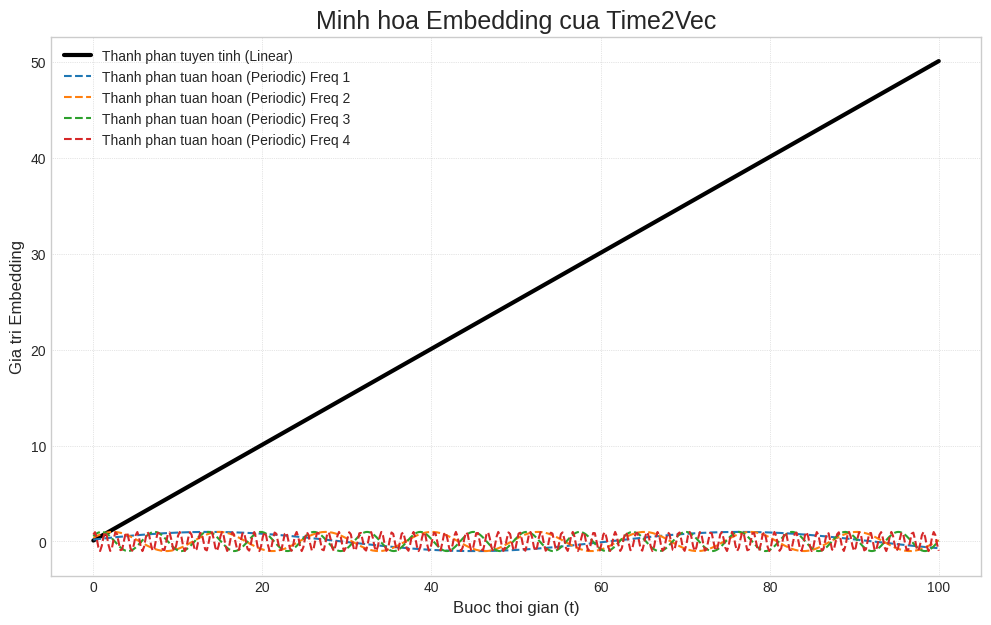

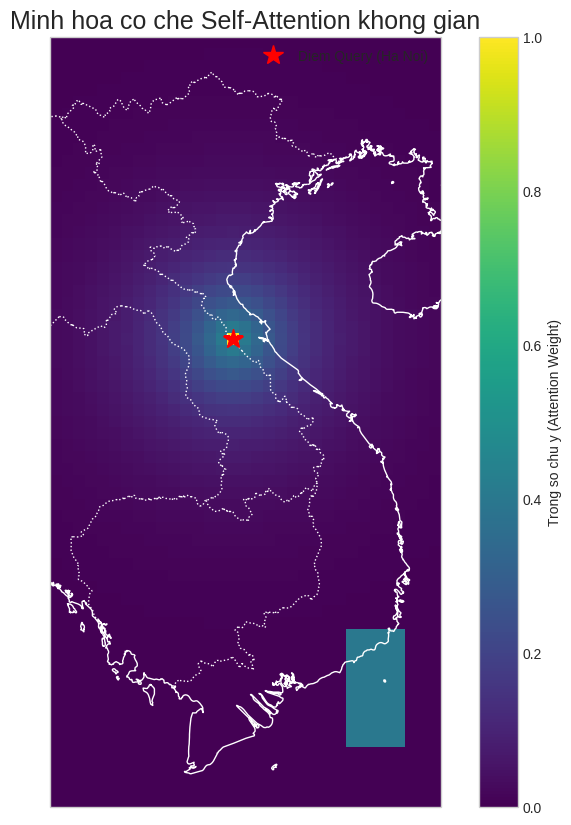

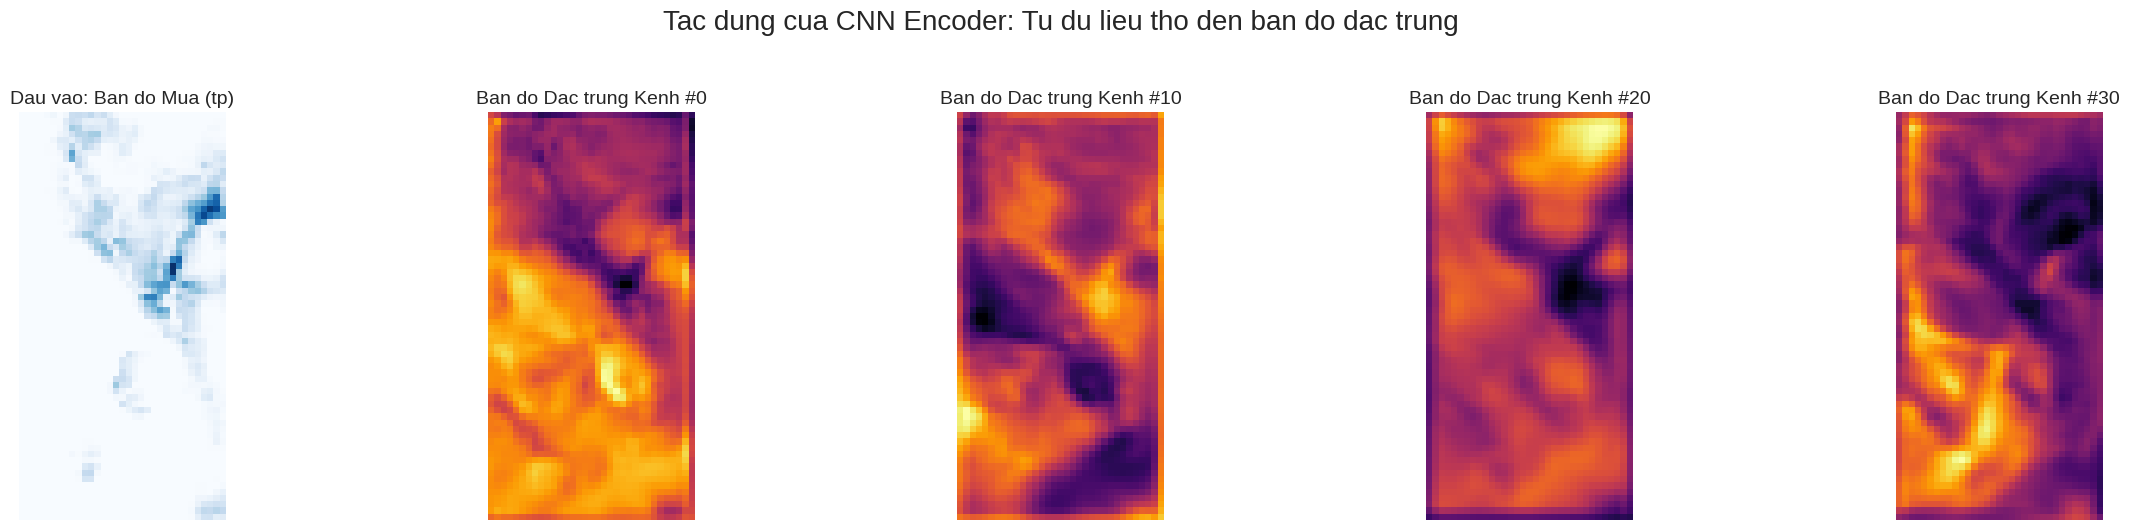



🎯 HOAN TAT TRUC QUAN HOA LY THUYET.


In [ ]:
# =============================================================================
# CELL 4: TRUC QUAN HOA CAC KHAI NIEM LY THUYET CUA MO HINH FECT
# =============================================================================
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

print("\n\n--- H. TRUC QUAN HOA CAC CO CHE LY THUYET CUA MO HINH ---")
plt.style.use('seaborn-v0_8-whitegrid')

# --- H1. Truc quan hoa Time2Vec Embedding (cho slide giai thich Time2Vec) ---

# Gia lap mot lop Time2Vec
class Time2VecViz(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Time2VecViz, self).__init__()
        self.w0 = nn.parameter.Parameter(torch.tensor([[0.5]]))
        self.b0 = nn.parameter.Parameter(torch.tensor([[0.1]]))
        # Cac trong so duoc chon de tao ra cac tan so khac nhau
        self.w = nn.parameter.Parameter(torch.tensor([[0.1, 0.5, 1.0, 5.0]]))
        self.b = nn.parameter.Parameter(torch.tensor([[0.2, 0.4, 0.6, 0.8]]))
    def forward(self, t):
        if t.dim() < 2:
            t = t.unsqueeze(-1)
        v_tuyen_tinh = torch.matmul(t, self.w0) + self.b0
        v_tuan_hoan = torch.sin(torch.matmul(t, self.w) + self.b)
        return torch.cat([v_tuyen_tinh, v_tuan_hoan], -1)

time2vec_viz = Time2VecViz(1, 5)
buoc_thoi_gian = torch.linspace(0, 100, 500)
embedding_thoi_gian = time2vec_viz(buoc_thoi_gian).detach().numpy()

plt.figure(figsize=(12, 7))
plt.plot(buoc_thoi_gian, embedding_thoi_gian[:, 0], label='Thanh phan tuyen tinh (Linear)', linewidth=3, color='black')
for i in range(1, 5):
    plt.plot(buoc_thoi_gian, embedding_thoi_gian[:, i], label=f'Thanh phan tuan hoan (Periodic) Freq {i}', linestyle='--')

plt.title('Minh hoa Embedding cua Time2Vec', fontsize=18)
plt.xlabel('Buoc thoi gian (t)', fontsize=12)
plt.ylabel('Gia tri Embedding', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.savefig(os.path.join(output_dir, 'viz_time2vec_khai_niem.png'), dpi=150, bbox_inches='tight')
plt.show()


# --- H2. Truc quan hoa Co che Self-Attention (cho slide giai thich Transformer) ---

# Gia lap trong so attention cho mot diem o Ha Noi
# Kich thuoc: (65, 33) tuong ung voi (lat, lon)
ban_do_attention = np.zeros((N_LAT, N_LON))
ha_noi_lat, ha_noi_lon = 25, 15  # toa do gan dung cua Ha Noi tren luoi

# Tao cac vung anh huong gia lap
# 1. Tu chu y vao chinh no (cao nhat)
ban_do_attention[ha_noi_lat, ha_noi_lon] = 1.0
# 2. Chu y vao cac diem lan can
for i in range(N_LAT):
    for j in range(N_LON):
        khoang_cach = np.sqrt((i - ha_noi_lat)**2 + (j - ha_noi_lon)**2)
        if khoang_cach > 0:
            ban_do_attention[i, j] += 0.5 * np.exp(-khoang_cach / 5)
# 3. Gia lap mot vung lien ket xa (teleconnection) o Bien Dong
ban_do_attention[50:60, 25:30] += 0.4

# Chuan hoa giong softmax
ban_do_attention = (ban_do_attention - ban_do_attention.min()) / (ban_do_attention.max() - ban_do_attention.min())

plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
gia_tri_lat = test_dataset.ds['latitude'].values
gia_tri_lon = test_dataset.ds['longitude'].values
pcm = ax.pcolormesh(gia_tri_lon, gia_tri_lat, ban_do_attention, cmap='viridis', shading='auto')

ax.add_feature(cfeature.COASTLINE, edgecolor='white')
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='white')
ax.plot(gia_tri_lon[ha_noi_lon], gia_tri_lat[ha_noi_lat], 'r*', markersize=15, label='Diem Query (Ha Noi)')

plt.colorbar(pcm, ax=ax, orientation='vertical', pad=0.05, label='Trong so chu y (Attention Weight)')
plt.title('Minh hoa co che Self-Attention khong gian', fontsize=18)
plt.legend()
plt.savefig(os.path.join(output_dir, 'viz_attention_khai_niem.png'), dpi=150, bbox_inches='tight')
plt.show()


# --- H3. Truc quan hoa Tac dung cua CNN Encoder (cho slide giai thich CNN) ---
# Lay mot mau du lieu thuc te
mau_du_lieu, _, _ = test_dataset[800]  # cung case study mua lon
anh_dau_vao = mau_du_lieu[0, :, :, :].unsqueeze(0).permute(0, 3, 1, 2)  # (B, C, H, W)

# Lay dau ra cua lop CNN dau tien tu model that
model.cpu()  # dua model ve CPU
with torch.no_grad():
    ban_do_dac_trung = model.cnn_encoder[0](anh_dau_vao.cpu())  # Conv2d thu 1
    ban_do_dac_trung = model.cnn_encoder[1](ban_do_dac_trung)   # GELU
    ban_do_dac_trung = model.cnn_encoder[2](ban_do_dac_trung)   # Conv2d thu 2

# Chon mot so kenh de truc quan hoa
kenh_hien_thi = [0, 10, 20, 30]
fig, axes = plt.subplots(1, len(kenh_hien_thi) + 1, figsize=(25, 5))
fig.suptitle('Tac dung cua CNN Encoder: Tu du lieu tho den ban do dac trung', fontsize=20, y=1.05)

# Anh dau vao (bien mua)
anh_mua = anh_dau_vao[0, ALL_FEATURES.index('tp'), :, :].numpy()
axes[0].imshow(anh_mua, cmap='Blues')
axes[0].set_title('Dau vao: Ban do Mua (tp)', fontsize=14)
axes[0].axis('off')

# Ve cac ban do dac trung
for i, kenh in enumerate(kenh_hien_thi):
    ax = axes[i + 1]
    fm_slice = ban_do_dac_trung[0, kenh, :, :].numpy()
    ax.imshow(fm_slice, cmap='inferno')
    ax.set_title(f'Ban do Dac trung Kenh #{kenh}', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'viz_cnn_encoder_khai_niem.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n\n🎯 HOAN TAT TRUC QUAN HOA LY THUYET.")


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


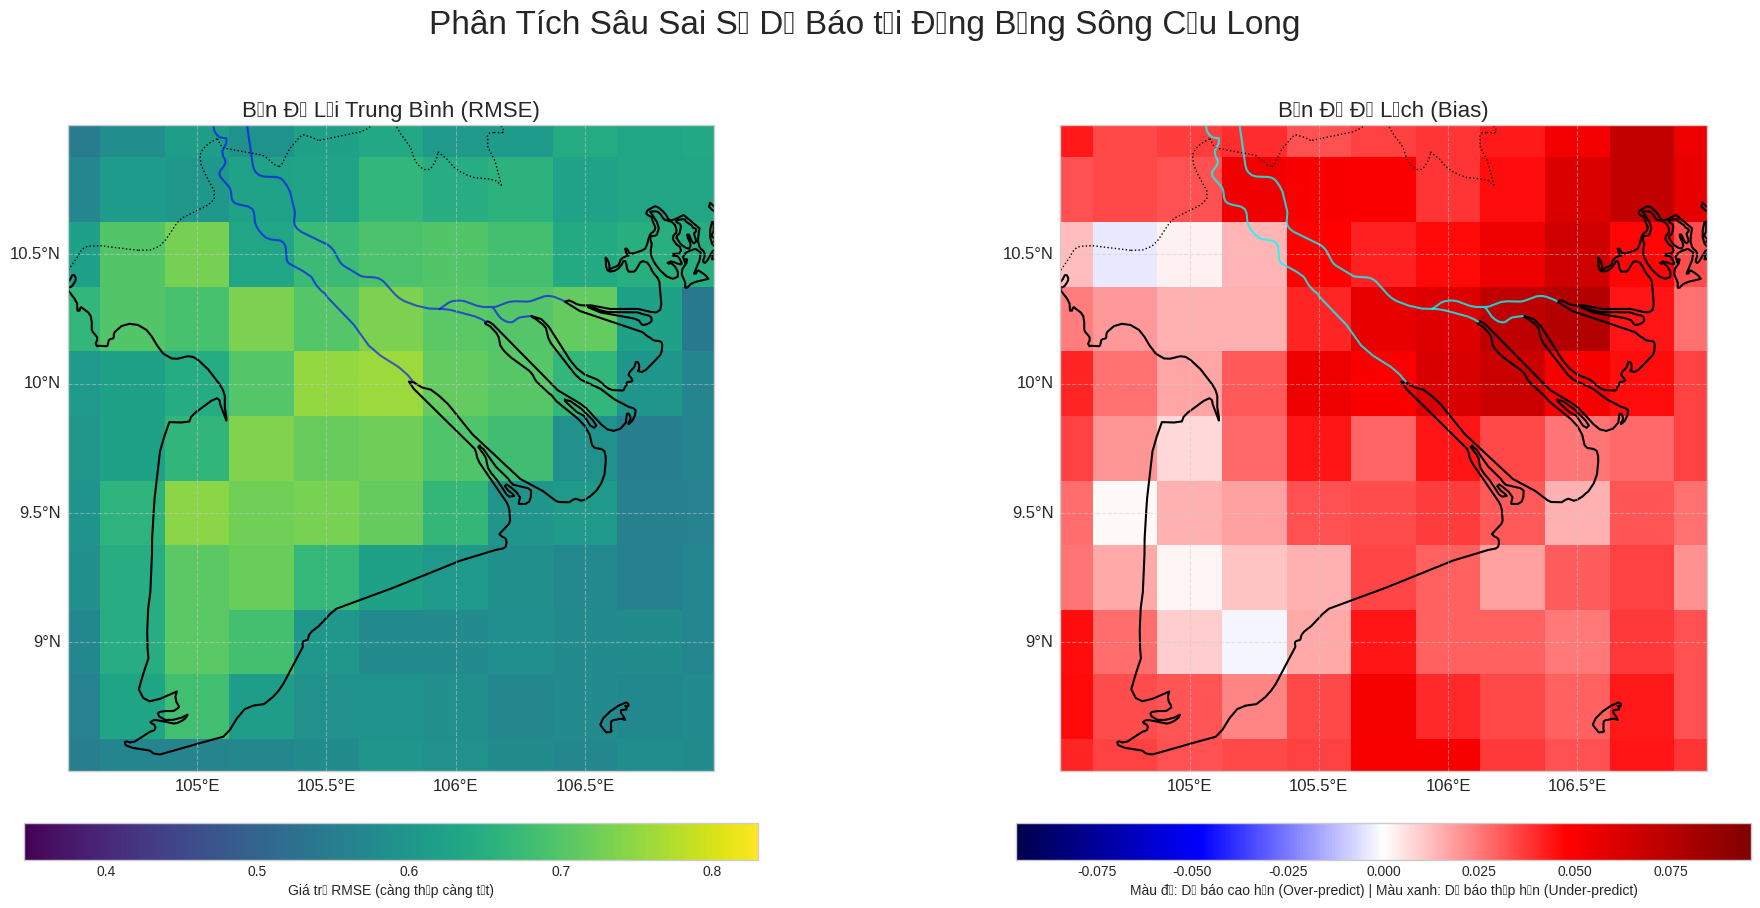

In [ ]:
# ==============================================================================
# PHÂN TÍCH SÂU: ZOOM VÀO ĐỒNG BẰNG SÔNG CỬU LONG
# ==============================================================================

# --- BƯỚC 1: ĐỊNH NGHĨA KHU VỰC ĐỊA LÝ CỦA ĐỒNG BẰNG SÔNG CỬU LONG ---
# Toạ độ được chọn để bao phủ toàn bộ khu vực và một phần biển lân cận.
# Định dạng: [kinh độ Tây, kinh độ Đông, vĩ độ Nam, vĩ độ Bắc]
mekong_delta_bounds = [104.5, 107.0, 8.5, 11.0]

# --- BƯỚC 2: TẠO HÀM VẼ BIỂU ĐỒ CHUYÊN BIỆT CHO KHU VỰC NÀY ---
# Hàm này tái sử dụng logic vẽ cũ nhưng thêm vào chức năng "zoom" và các chi tiết địa lý.

def plot_zoomed_spatial_error_maps(y_true, y_pred, test_ds, area_bounds, area_name):
    """
    Vẽ bản đồ phân bố RMSE và Bias, zoom vào một khu vực cụ thể.
    """
    lat_vals = test_ds.ds['latitude'].values
    lon_vals = test_ds.ds['longitude'].values

    # Tính toán sai số trên từng điểm lưới
    squared_error = (y_pred - y_true)**2
    bias_error = y_pred - y_true

    # Lấy trung bình theo chiều thời gian
    rmse_map = np.sqrt(squared_error.mean(axis=0))
    bias_map = bias_error.mean(axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(20, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    fig.suptitle(f'Phân Tích Sâu Sai Số Dự Báo tại {area_name}', fontsize=24, y=0.95)

    # ----------- BẢN ĐỒ LỖI TRUNG BÌNH (RMSE) -----------
    ax1 = axes[0]
    pcm1 = ax1.pcolormesh(lon_vals, lat_vals, rmse_map, cmap='viridis', shading='auto', transform=ccrs.PlateCarree())

    # Thêm các chi tiết địa lý
    ax1.add_feature(cfeature.COASTLINE, linewidth=1.5)
    ax1.add_feature(cfeature.BORDERS, linestyle=':')
    ax1.add_feature(cfeature.RIVERS, color='blue', alpha=0.6, linewidth=1.5) # Thêm sông ngòi

    # **LỆNH ZOOM QUAN TRỌNG NHẤT**
    ax1.set_extent(area_bounds, crs=ccrs.PlateCarree())

    # Thêm lưới toạ độ để dễ định vị
    gl1 = ax1.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl1.top_labels = False
    gl1.right_labels = False
    gl1.xlabel_style = {'size': 12}
    gl1.ylabel_style = {'size': 12}

    ax1.set_title("Bản Đồ Lỗi Trung Bình (RMSE)", fontsize=16)
    fig.colorbar(pcm1, ax=ax1, orientation='horizontal', pad=0.07, fraction=0.05, label='Giá trị RMSE (càng thấp càng tốt)')

    # ----------- BẢN ĐỒ ĐỘ LỆCH (BIAS) -----------
    ax2 = axes[1]
    bias_lim = np.max(np.abs(bias_map)) # Cân bằng thang màu
    pcm2 = ax2.pcolormesh(lon_vals, lat_vals, bias_map, cmap='seismic', vmin=-bias_lim, vmax=bias_lim, shading='auto', transform=ccrs.PlateCarree())

    # Thêm các chi tiết địa lý
    ax2.add_feature(cfeature.COASTLINE, linewidth=1.5)
    ax2.add_feature(cfeature.BORDERS, linestyle=':')
    ax2.add_feature(cfeature.RIVERS, color='cyan', alpha=0.8, linewidth=1.5) # Màu khác để nổi bật

    # **LỆNH ZOOM QUAN TRỌNG NHẤT**
    ax2.set_extent(area_bounds, crs=ccrs.PlateCarree())

    # Thêm lưới toạ độ
    gl2 = ax2.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl2.top_labels = False
    gl2.right_labels = False
    gl2.xlabel_style = {'size': 12}
    gl2.ylabel_style = {'size': 12}

    ax2.set_title("Bản Đồ Độ Lệch (Bias)", fontsize=16)
    fig.colorbar(pcm2, ax=ax2, orientation='horizontal', pad=0.07, fraction=0.05, label='Màu đỏ: Dự báo cao hơn (Over-predict) | Màu xanh: Dự báo thấp hơn (Under-predict)')

    plt.tight_layout(rect=[0, 0.05, 1, 0.92])
    plt.show()


# --- BƯỚC 3: GỌI HÀM ĐỂ VẼ BIỂU ĐỒ CHO ĐỒNG BẰNG SÔNG CỬU LONG ---
# Giả định các biến ground_truths_tensor, predictions_tensor, test_dataset đã tồn tại
plot_zoomed_spatial_error_maps(
    ground_truths_tensor.numpy(),
    predictions_tensor.numpy(),
    test_dataset,
    mekong_delta_bounds,
    "Đồng Bằng Sông Cửu Long"
)